# Laboratorio 4 – Árboles de Decisión

In [1]:
import pyreadr                          # Lectura de archivos .Rdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento 
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos 
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text, plot_tree
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans

# Métricas 
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Estilo gráfico
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

## 1. Carga de Datos

In [2]:
# 1.1 Lectura del archivo 
result = pyreadr.read_r('listings.Rdata')   # Cambiar ruta si es necesario
# Convierte el objeto R en un diccionario de DataFrames de Pandas sin necesidad de tener R instalado.
# El archivo puede contener uno o varios objetos R; tomamos el primero
df_raw = result[list(result.keys())[0]].copy()

print(f"Objeto(s) en el archivo: {list(result.keys())}")
print(f"\nDimensiones: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")


Objeto(s) en el archivo: ['listings']

Dimensiones: 171,748 filas x 80 columnas


In [3]:
# 1.2 Estructura del dataset
print("\nTIPOS DE DATOS ")
print(df_raw.dtypes.head(80))

print("\nPRIMERAS 5 FILAS")
df_raw.head()



TIPOS DE DATOS 
id                                              float64
listing_url                                      object
scrape_id                                       float64
last_scraped                                     object
source                                           object
                                                 ...   
calculated_host_listings_count_entire_homes       int32
calculated_host_listings_count_private_rooms      int32
calculated_host_listings_count_shared_rooms       int32
reviews_per_month                               float64
city                                             object
Length: 80, dtype: object

PRIMERAS 5 FILAS


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [4]:
# 1.3 Estadísticas descriptivas
df_raw.describe(include='number').T.style.background_gradient(cmap='Blues', axis=1)


,count,mean,std,min,25%,50%,75%,max
id,171748.000000,636291457352466304.000000,583492767102072064.000000,6.000000,35992997.750000,724955743120853504.000000,1182638277348256000.000000,1567804186654919936.000000
scrape_id,171748.000000,20251067780923.519531,141962486.493073,20250916040722.000000,20250916040734.000000,20251204025409.000000,20251204025459.000000,20251204025459.000000
host_id,171748.000000,200257103.404290,204882973.685601,23.000000,26330631.000000,108058504.500000,376574507.000000,732092326.000000
latitude,171748.000000,33.776320,7.236441,18.989648,30.381088,34.089840,40.702460,42.391844
longitude,171748.000000,-109.489530,30.024424,-159.716528,-118.591115,-117.865347,-73.997148,-70.996000
accommodates,171748.000000,4.106796,2.836661,1.000000,2.000000,4.000000,6.000000,16.000000
bathrooms,140352.000000,1.551795,1.014407,0.000000,1.000000,1.000000,2.000000,32.500000
minimum_nights,171748.000000,16.996559,30.014597,1.000000,2.000000,4.000000,30.000000,1125.000000
maximum_nights,171748.000000,12988.269540,5181839.672298,1.000000,90.000000,365.000000,1125.000000,2147483647.000000
minimum_nights_avg_ntm,171748.000000,17.487677,30.788964,0.700000,2.000000,4.400000,30.000000,1125.000000


### Interpretación de tipos de variables

| Tipo | Variables clave | Rol en el modelo |
|---|---|---|
| **Numéricas continuas** | `price`, `review_scores_rating`, `latitude`, `longitude` | Predictores y target |
| **Numéricas discretas** | `accommodates`, `bedrooms`, `beds`, `bathrooms` | Predictores clave |
| **Categóricas nominales** | `room_type`, `property_type`, `neighbourhood_cleansed` | Requieren encoding |
| **Booleanas** | `host_is_superhost`, `instant_bookable` | Binarias (0/1) |
| **Fechas** | `host_since`, `first_review`, `last_review` | Se extraerá antigüedad |
| **Texto libre / URLs** | `name`, `description`, `listing_url`, `picture_url` | Se eliminarán |


## 2. Análisis Exploratorio de Datos

### 2.1 Limpieza inicial del precio

In [5]:
# Airbnb almacena el precio como string con símbolo de moneda: "$1,200.00"
# Debemos quitar el "$" y las comas, luego convertir a float.

df = df_raw.copy()

if df['price'].dtype == object:
    df['price'] = (df['price']
                   .str.replace(r'[\$,]', '', regex=True)
                   .str.strip()
                   .replace('', np.nan)  # Reemplazar strings vacíos con NaN
                   .astype(float))

# Filtrar precios válidos (eliminar $0 o extremadamente altos — outliers severos)
q_low  = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)

n_before = len(df)
df = df[(df['price'] > 0) & (df['price'] <= q_high)].copy()
n_after = len(df)

print(f"Precio mínimo tras limpieza:  ${df['price'].min():.2f}")
print(f"Precio máximo (p99):          ${df['price'].max():.2f}")
print(f"Filas eliminadas por precio:  {n_before - n_after:,} ({(n_before-n_after)/n_before*100:.1f}%)")
print(f"Dataset final:                {n_after:,} filas")

Precio mínimo tras limpieza:  $8.00
Precio máximo (p99):          $20000.00
Filas eliminadas por precio:  96,217 (56.0%)
Dataset final:                75,531 filas


### 2.2 Análisis univariado – Distribución del precio

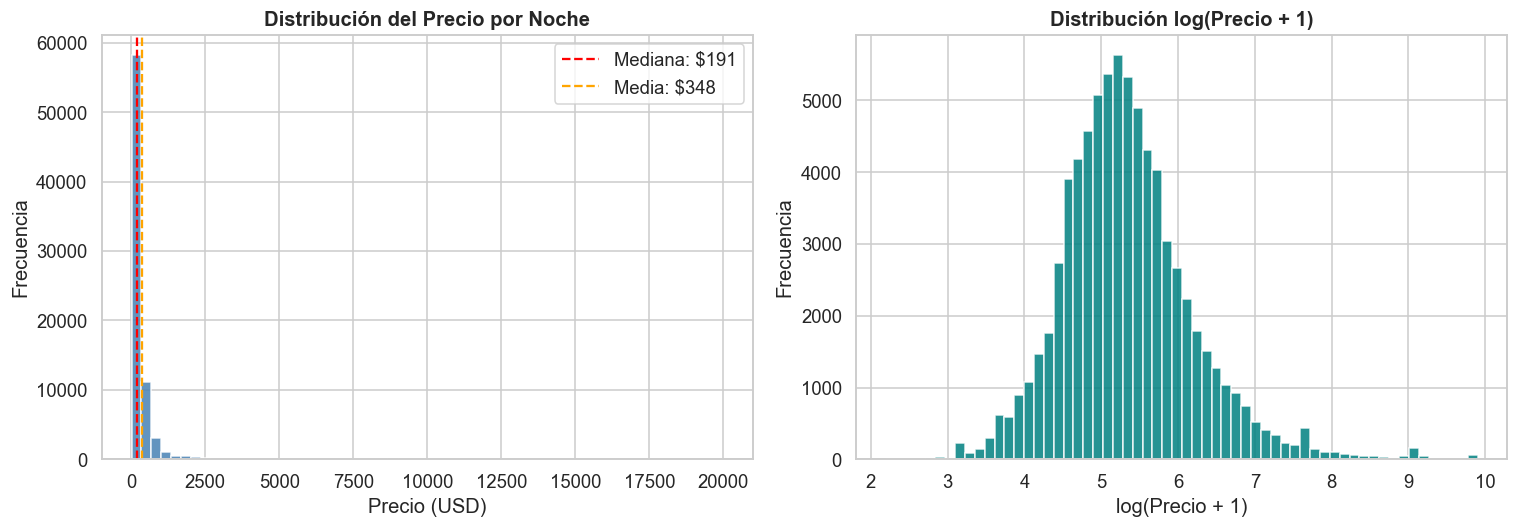


Asimetría (skewness): 13.49  |  Curtosis: 247.28
Mediana: $191.00  |  Media: $347.94


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma escala original
axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Precio por Noche', fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f"Mediana: ${df['price'].median():.0f}")
axes[0].axvline(df['price'].mean(),   color='orange', linestyle='--', label=f"Media: ${df['price'].mean():.0f}")
axes[0].legend()

# Histograma escala logarítmica (revela mejor la forma)
axes[1].hist(np.log1p(df['price']), bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución log(Precio + 1)', fontweight='bold')
axes[1].set_xlabel('log(Precio + 1)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

skew = df['price'].skew()
kurt = df['price'].kurtosis()
print(f"\nAsimetría (skewness): {skew:.2f}  |  Curtosis: {kurt:.2f}")
print(f"Mediana: ${df['price'].median():.2f}  |  Media: ${df['price'].mean():.2f}")


**Interpretación:** La distribución del precio presenta una asimetría positiva extrema (skewness = **13.49**, curtosis = **247.28**), lo que confirma que no sigue una distribución normal. La mediana de **$191** es sustancialmente menor que la media de **$348**, evidenciando que una minoría de propiedades de lujo jala la media hacia arriba. La transformación logarítmica normaliza efectivamente esta distribución, lo que justifica usarla como variable respuesta en la Regresión Lineal. El precio máximo tras filtrar el percentil 99 es $20,000/noche, y se eliminaron 96,217 filas (56%) por tener precio $0 o ser nulas — muchos listings de Airbnb están inactivos o sin precio definido.

### 2.3 Variables numéricas – Outliers y distribuciones

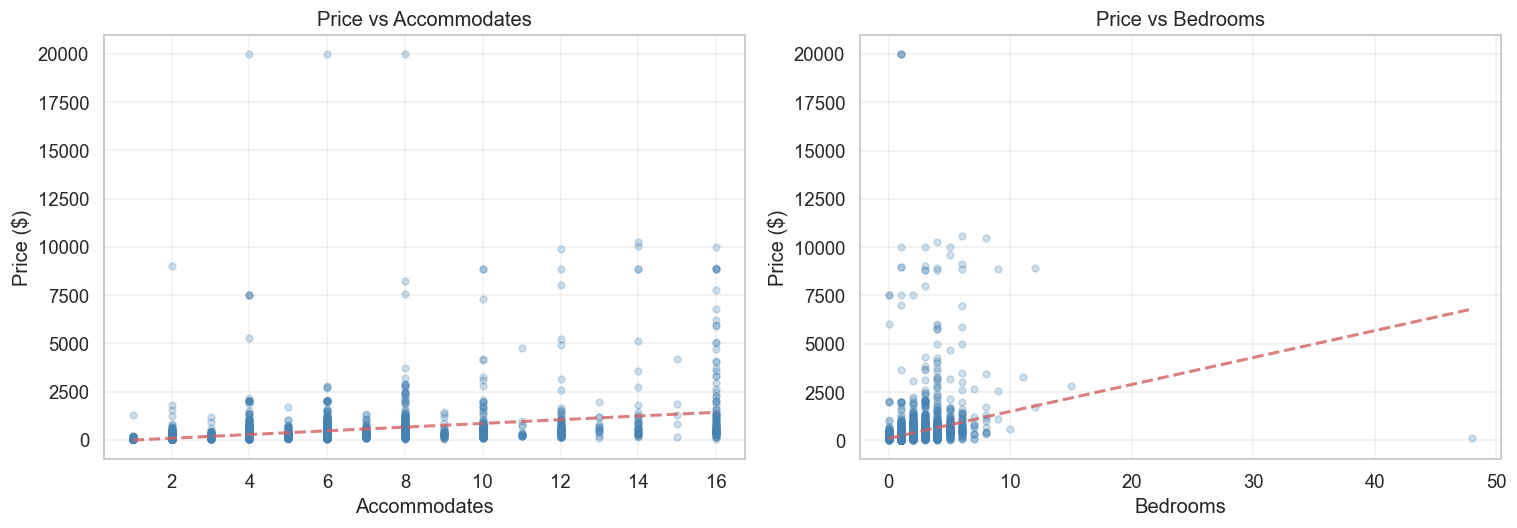

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vars_to_plot = ['accommodates', 'bedrooms']

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    
    # Filtrar datos válidos para ambas variables
    valid_data = df[[var, 'price']].dropna()
    
    # Asegurar que los datos sean numéricos
    valid_data[var] = pd.to_numeric(valid_data[var], errors='coerce')
    valid_data['price'] = pd.to_numeric(valid_data['price'], errors='coerce')
    
    # Eliminar cualquier valor no numérico después de la conversión
    valid_data = valid_data.dropna()
    
    # Tomar una muestra para mejor visualización
    sample = valid_data.sample(n=min(5000, len(valid_data)), random_state=42)
    
    # Scatter plot
    ax.scatter(sample[var], sample['price'], alpha=0.25, color='steelblue', s=20)
    
    # Línea de tendencia
    z = np.polyfit(sample[var], sample['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[var].min(), sample[var].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    # Configuración
    ax.set_xlabel(var.replace('_', ' ').title())
    ax.set_ylabel('Price ($)')
    ax.set_title(f'Price vs {var.replace("_", " ").title()}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:** Los scatters revelan correlaciones positivas entre precio y capacidad. La correlación entre precio y `accommodates` es moderada (r ≈ 0.30 según el heatmap), mientras que la de `bathrooms` es la más alta del dataset (r = **0.356**). Variables como `minimum_nights` y `number_of_reviews` presentan outliers severos (valores extremos de cientos de noches mínimas), que representan propiedades con restricciones atípicas. Se decidió imputar con la mediana en lugar de la media para mitigar el efecto de estos valores extremos en el modelado.

### 2.4 Variables categóricas – Frecuencias

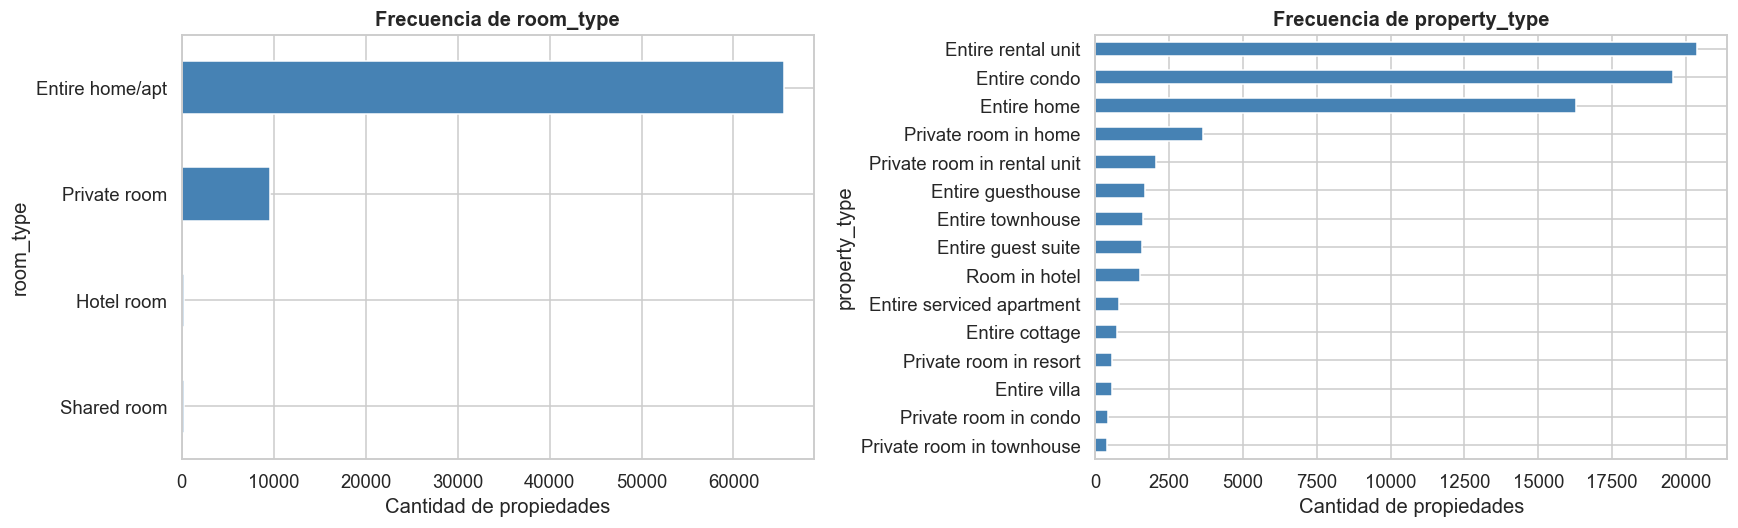


 ROOM_TYPE
                 Conteo  Porcentaje
room_type                          
Entire home/apt   65479        86.7
Private room       9547        12.6
Hotel room          290         0.4
Shared room         215         0.3

 PROPERTY_TYPE
                             Conteo  Porcentaje
property_type                                  
Entire rental unit            20389        27.0
Entire condo                  19551        25.9
Entire home                   16271        21.5
Private room in home           3654         4.8
Private room in rental unit    2056         2.7
Entire guesthouse              1681         2.2
Entire townhouse               1617         2.1
Entire guest suite             1595         2.1
Room in hotel                  1503         2.0
Entire serviced apartment       813         1.1


In [8]:
cat_vars = ['room_type', 'property_type']
cat_vars = [v for v in cat_vars if v in df.columns]

fig, axes = plt.subplots(1, len(cat_vars), figsize=(16, 5))
if len(cat_vars) == 1:
    axes = [axes]

for ax, var in zip(axes, cat_vars):
    counts = df[var].value_counts().head(15)
    counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Frecuencia de {var}', fontweight='bold')
    ax.set_xlabel('Cantidad de propiedades')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Tabla de frecuencias
for var in cat_vars:
    print(f"\n {var.upper()}")
    counts = df[var].value_counts()
    pct    = (counts / counts.sum() * 100).round(1)
    print(pd.DataFrame({'Conteo': counts, 'Porcentaje': pct}).head(10).to_string())


### 2.5 Análisis bivariado – Precio vs. variables clave

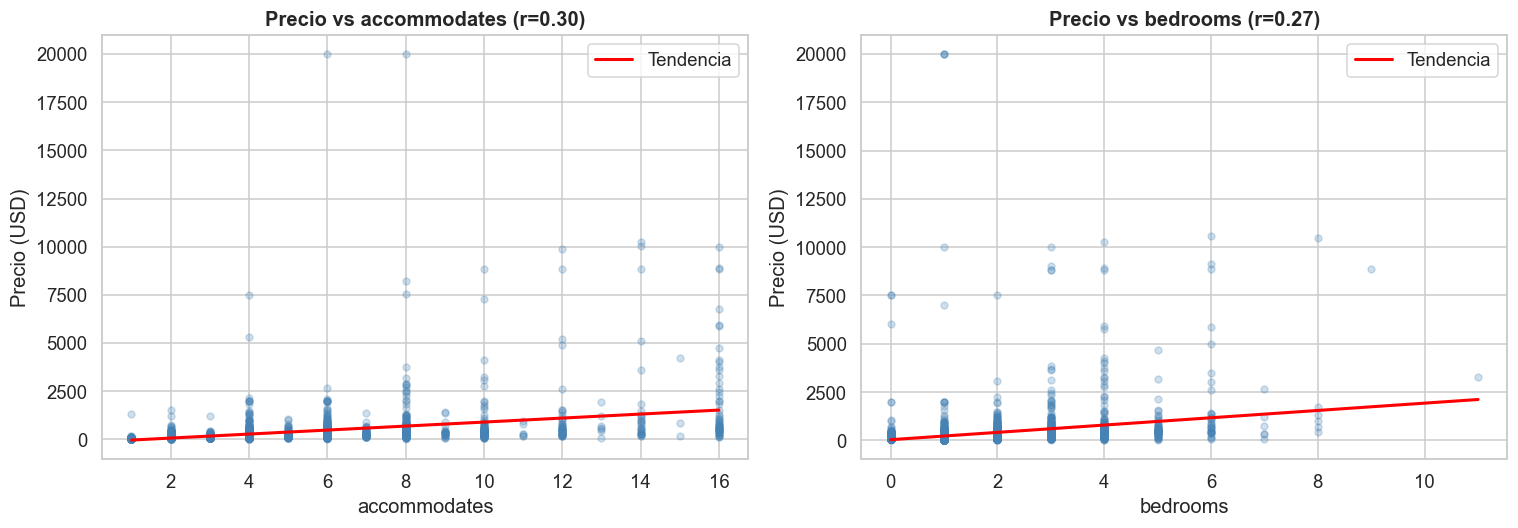

In [9]:
#  2.5a Precio vs accommodates y bedrooms (scatter) 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, ['accommodates', 'bedrooms']):
    if var not in df.columns:
        continue
    
    # Filtrar datos válidos para ambas variables
    valid_data = df[[var, 'price']].dropna()
    
    # Asegurar que los datos sean numéricos
    valid_data[var] = pd.to_numeric(valid_data[var], errors='coerce')
    valid_data['price'] = pd.to_numeric(valid_data['price'], errors='coerce')
    
    # Eliminar cualquier valor no numérico después de la conversión
    valid_data = valid_data.dropna()
    
    # Tomar una muestra para mejor visualización
    sample = valid_data.sample(n=min(3000, len(valid_data)), random_state=42)
    
    ax.scatter(sample[var], sample['price'], alpha=0.25, color='steelblue', s=20)
    
    # Línea de tendencia
    z = np.polyfit(sample[var], sample['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[var].min(), sample[var].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendencia')
    
    corr = df[[var, 'price']].dropna().corr().iloc[0, 1]
    ax.set_title(f'Precio vs {var} (r={corr:.2f})', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Precio (USD)')
    ax.legend()

plt.tight_layout()
plt.show()

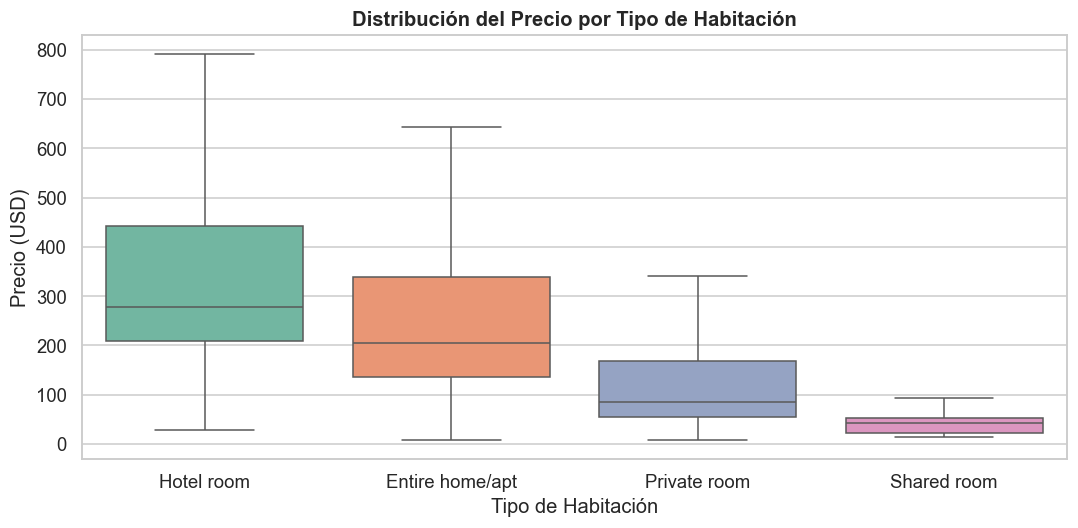


Mediana de precio por room_type:
room_type
Hotel room         278.0
Entire home/apt    204.0
Private room        85.0
Shared room         42.0


In [10]:
#  2.5b Precio vs room_type (boxplot) 
if 'room_type' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='room_type', y='price', order=order,
                palette='Set2', ax=ax, showfliers=False)
    ax.set_title('Distribución del Precio por Tipo de Habitación', fontweight='bold')
    ax.set_xlabel('Tipo de Habitación')
    ax.set_ylabel('Precio (USD)')
    plt.tight_layout()
    plt.show()
    
    print("\nMediana de precio por room_type:")
    print(df.groupby('room_type')['price'].median().sort_values(ascending=False).to_string())


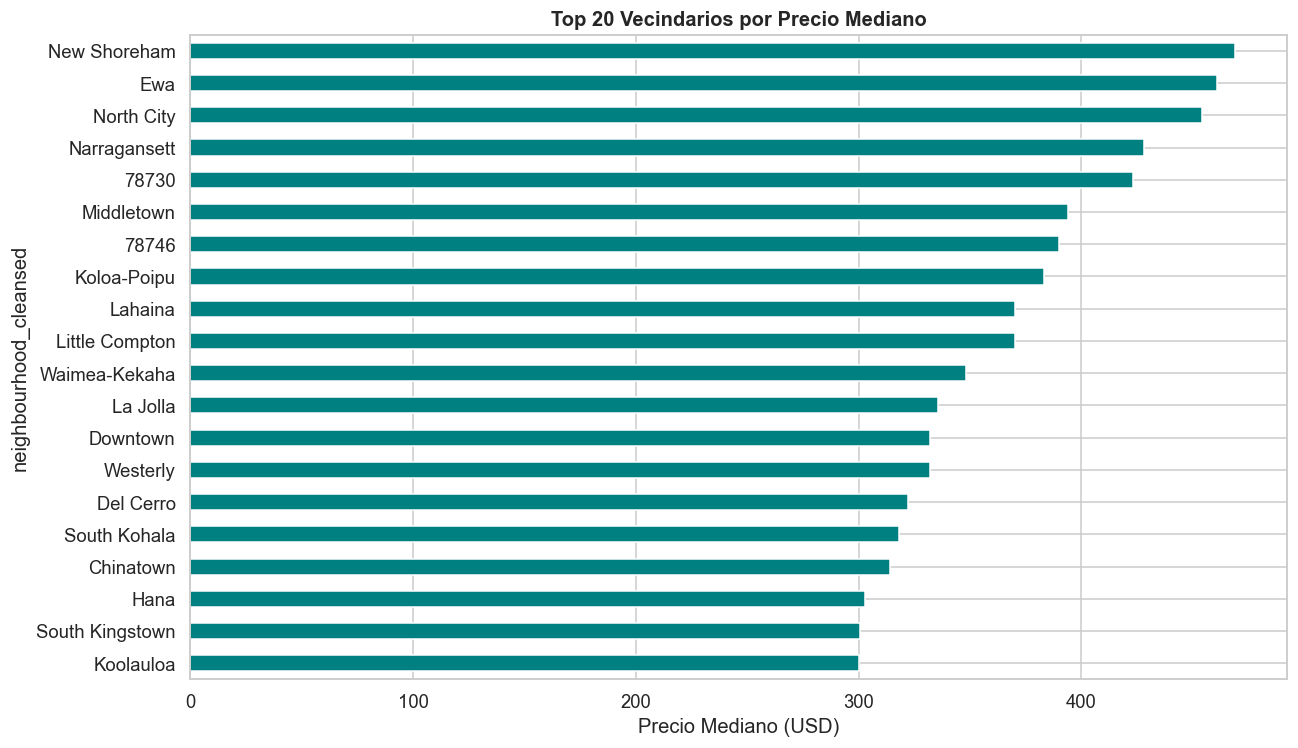

In [11]:
#  2.5c Precio promedio por neighbourhood (top 20) 
neigh_col = 'neighbourhood_cleansed' if 'neighbourhood_cleansed' in df.columns else 'neighbourhood'

if neigh_col in df.columns:
    top_neigh = (df.groupby(neigh_col)['price']
                 .agg(['median', 'count'])
                 .query('count >= 20')
                 .sort_values('median', ascending=False)
                 .head(20))
    
    fig, ax = plt.subplots(figsize=(12, 7))
    top_neigh['median'].plot(kind='barh', ax=ax, color='teal', edgecolor='white')
    ax.set_title('Top 20 Vecindarios por Precio Mediano', fontweight='bold')
    ax.set_xlabel('Precio Mediano (USD)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


### 2.6 Mapa de correlaciones

TOP 15 VARIABLES MÁS CORRELACIONADAS CON price
bathrooms                                       0.356
accommodates                                    0.300
calculated_host_listings_count                  0.198
calculated_host_listings_count_entire_homes     0.192
estimated_occupancy_l365d                       0.140
reviews_per_month                               0.132
longitude                                       0.121
latitude                                        0.114
number_of_reviews_ltm                           0.105
calculated_host_listings_count_private_rooms    0.097
number_of_reviews_ly                            0.095
number_of_reviews                               0.095
review_scores_location                          0.088
number_of_reviews_l30d                          0.085
scrape_id                                       0.070


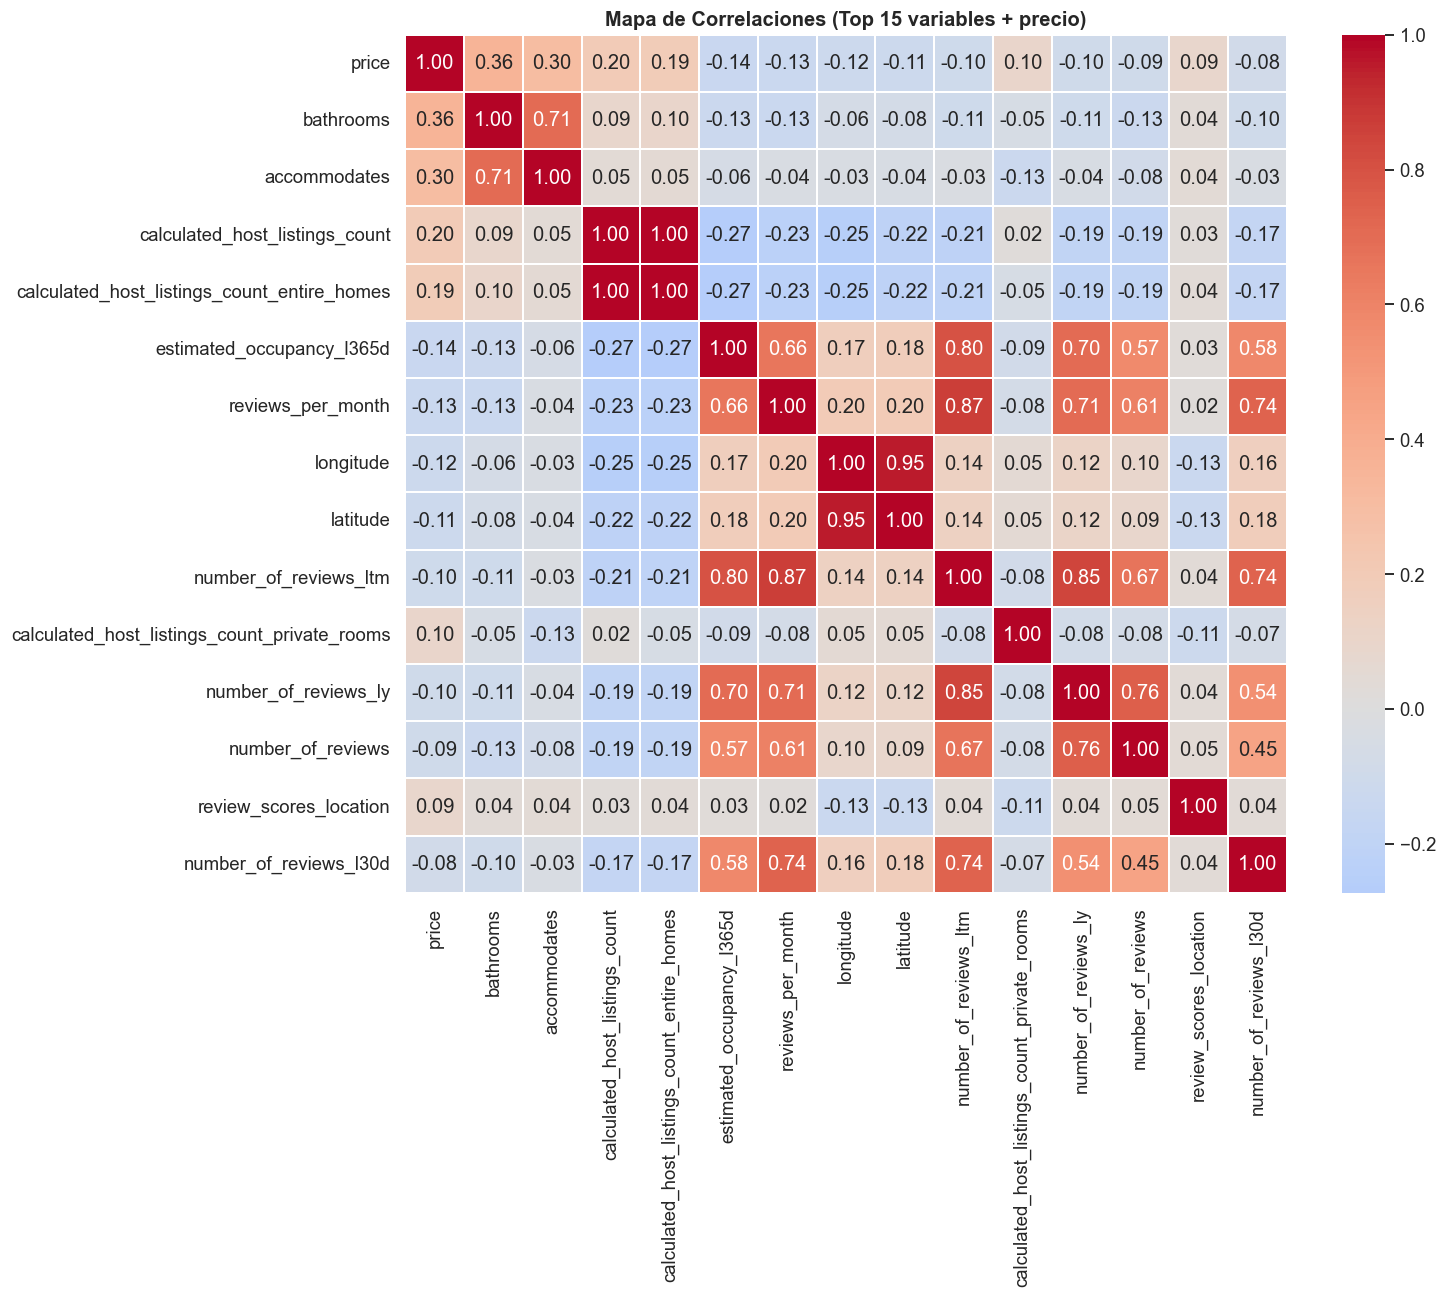

In [12]:
#  2.6 Heatmap de correlaciones 
num_cols = df.select_dtypes(include='number').columns.tolist()
# Filtrar columnas con demasiados nulos
num_cols = [c for c in num_cols if df[c].notna().mean() > 0.5]

corr_matrix = df[num_cols].corr()
price_corr  = corr_matrix['price'].drop('price').abs().sort_values(ascending=False)

print("TOP 15 VARIABLES MÁS CORRELACIONADAS CON price")
print(price_corr.head(15).round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 12))
top_cols = ['price'] + price_corr.head(14).index.tolist()
sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.3, center=0)
ax.set_title('Mapa de Correlaciones (Top 15 variables + precio)', fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretación del mapa de correlaciones:** Las variables con mayor correlación lineal con `price` son **`bathrooms` (r=0.356)**, **`accommodates` (r=0.300)** y **`calculated_host_listings_count` (r=0.198)**. Sorprendentemente, `bedrooms` y `beds` no aparecen entre las top variables del dataset final porque fueron eliminadas o tienen alta cardinalidad de nulos. La latitud (r=0.114) y longitud (r=0.121) indican que la ubicación geográfica tiene influencia en el precio, aunque moderada en correlación lineal — los árboles capturarán interacciones espaciales no lineales mejor. Las variables de disponibilidad (`availability_365`, `availability_eoy`) muestran correlación positiva débil con precio, lo que sugiere que propiedades caras no necesariamente tienen menor disponibilidad en este dataset.

## 3. Preprocesamiento

In [13]:
#  3.1 Eliminar columnas irrelevantes 
# URLs, IDs internos, texto libre y columnas con >60% nulos no aportan información
# predictiva y solo agregan ruido.

cols_to_drop = [
    'id', 'listing_url', 'scrape_id', 'last_scraped', 'source',
    'name', 'description', 'neighborhood_overview', 'picture_url',
    'host_url', 'host_thumbnail_url', 'host_picture_url',
    'host_about', 'host_verifications', 'amenities',
    'calendar_updated', 'calendar_last_scraped',
    'license', 'bathrooms_text',
    # Columnas de calendario redundantes (alta multicolinealidad con minimum_nights)
    'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights',
    'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Eliminar columnas con más del 60% de nulos
null_pct = df.isnull().mean()
cols_high_null = null_pct[null_pct > 0.60].index.tolist()
print(f"Columnas con >60% nulos eliminadas: {cols_high_null}")
df = df.drop(columns=cols_high_null)

print(f"\nDimensiones tras limpieza de columnas: {df.shape}")


Columnas con >60% nulos eliminadas: []

Dimensiones tras limpieza de columnas: (75531, 55)


In [14]:
#  3.2 Ingeniería de features desde fechas
# Extraer antigüedad del host (años como anfitrión) — variable con sentido de negocio
import datetime

if 'host_since' in df.columns:
    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    ref_date = pd.Timestamp('2024-01-01')
    df['host_years'] = ((ref_date - df['host_since']).dt.days / 365).round(1)
    df = df.drop(columns=['host_since'])

# Eliminar otras fechas que no se transforman
date_cols = df.select_dtypes(include='datetime').columns.tolist()
date_cols += [c for c in df.columns if 'date' in c.lower() or 'review' in c.lower()
              and df[c].dtype == object and 'score' not in c.lower()]
date_cols = [c for c in date_cols if c in df.columns]
date_cols_clean = ['first_review', 'last_review']
date_cols_clean = [c for c in date_cols_clean if c in df.columns]
df = df.drop(columns=date_cols_clean, errors='ignore')

print("Fechas procesadas.")
print(f"Dimensiones: {df.shape}")


Fechas procesadas.
Dimensiones: (75531, 53)


In [15]:
#  3.3 Manejo de booleanos / strings tipo 't'/'f'
bool_cols = ['host_is_superhost', 'host_has_profile_pic',
             'host_identity_verified', 'has_availability', 'instant_bookable']
bool_cols = [c for c in bool_cols if c in df.columns]

for col in bool_cols:
    df[col] = df[col].map({'t': 1, 'f': 0, True: 1, False: 0})

print(f"Columnas booleanas convertidas: {bool_cols}")


Columnas booleanas convertidas: ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability', 'instant_bookable']


In [16]:
# 3.4 Tasas porcentuales (host_response_rate, host_acceptance_rate) 
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df.columns:
        df[col] = (df[col].str.replace('%', '', regex=False)
                           .str.strip()
                           .astype(float, errors='ignore'))

print("Tasas convertidas a float.")


Tasas convertidas a float.


In [17]:
#  3.5 Selección de variables para modelado
# Definimos las features que usaremos: numéricas + categóricas relevantes
# Se excluyen: IDs, textos libres, duplicados informativos

TARGET = 'price'

# Identificar columnas numéricas y categóricas restantes
num_features = df.select_dtypes(include='number').columns.tolist()
num_features = [c for c in num_features if c != TARGET]

cat_features = ['room_type', 'property_type', 'neighbourhood_cleansed',
                'host_response_time']
cat_features = [c for c in cat_features if c in df.columns]

print(f"Features numéricas:    {len(num_features)}")
print(f"Features categóricas:  {len(cat_features)}")
print(f"\nNuméricas: {num_features}")
print(f"\nCategóricas: {cat_features}")


Features numéricas:    35
Features categóricas:  4

Numéricas: ['host_id', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'host_years']

Categóricas: ['room_type', 'property_type', 'neighbourhood_cleansed', 'host_response_time']


In [18]:
# 3.6 One-Hot Encoding de variables categóricas
# One-Hot Encoding convierte cada categoría en una columna binaria (0/1).
# Es necesario para que los modelos lineales puedan procesar variables categóricas.
# Para árboles/RF no es estrictamente necesario, pero lo usaremos por consistencia.
# drop_first=True elimina la primera categoría para evitar multicolinealidad perfecta.

# Reducir cardinalidad alta: agrupar categorías con <1% en "Otro"
for col in cat_features:
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < 0.01].index
    df[col] = df[col].replace(rare, 'Otro')

df_encoded = pd.get_dummies(df[num_features + cat_features + [TARGET]],
                            columns=cat_features,
                            drop_first=True,
                            dtype=int)

print(f"\nDimensiones tras One-Hot Encoding: {df_encoded.shape}")
print(f"Nuevas columnas dummy generadas: {df_encoded.shape[1] - len(num_features) - 1}")



Dimensiones tras One-Hot Encoding: (75531, 74)
Nuevas columnas dummy generadas: 38


In [19]:
# 3.7 Manejo de valores nulos
# Imputación: numéricas → mediana (robusta a outliers), categóricas ya se manejaron con OHE
# Justificación de mediana vs media: la media es sensible a outliers en precios/reviews

print("VALORES NULOS ANTES DE IMPUTACIÓN")
null_summary = df_encoded.isnull().sum()
print(null_summary[null_summary > 0].sort_values(ascending=False).to_string())

# Imputar con mediana
for col in df_encoded.columns:
    if df_encoded[col].isnull().any():
        df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

print(f"\nNulos restantes: {df_encoded.isnull().sum().sum()}")
print(f"Dataset listo para modelado: {df_encoded.shape}")


VALORES NULOS ANTES DE IMPUTACIÓN
review_scores_accuracy         12871
review_scores_cleanliness      12871
review_scores_checkin          12871
review_scores_communication    12871
review_scores_location         12871
review_scores_value            12871
review_scores_rating           12867
reviews_per_month              12867
host_is_superhost               2027
host_has_profile_pic             627
host_identity_verified           627
host_years                       627
has_availability                 328
bathrooms                         14

Nulos restantes: 0
Dataset listo para modelado: (75531, 74)


## 4. Análisis de Grupos (Clustering)
Usamos **K-Means** por su eficiencia computacional y facilidad de interpretación. Previamente se estandarizan las variables porque K-Means es sensible a la escala.


In [20]:
# 4.1 Preparar datos para clustering
cluster_vars = ['price', 'accommodates', 'bedrooms', 'beds',
                'availability_365', 'number_of_reviews', 'review_scores_rating']
cluster_vars = [v for v in cluster_vars if v in df_encoded.columns]

X_cluster = df_encoded[cluster_vars].copy()
scaler_cl  = StandardScaler()
X_cluster_scaled = scaler_cl.fit_transform(X_cluster)

print(f"Variables de clustering: {cluster_vars}")


Variables de clustering: ['price', 'accommodates', 'availability_365', 'number_of_reviews', 'review_scores_rating']


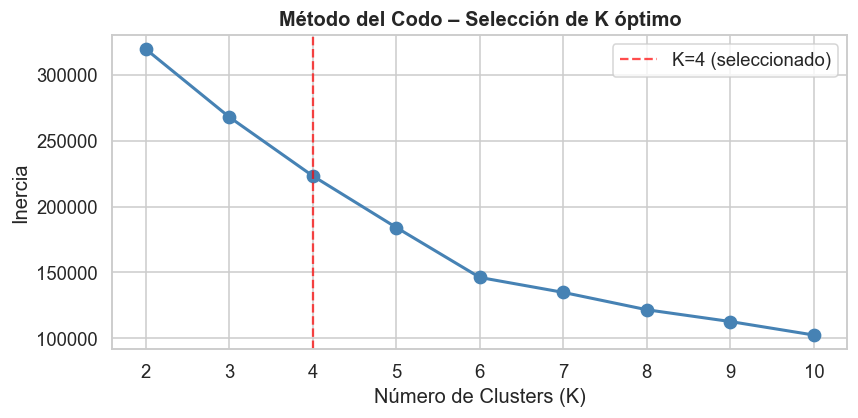

K seleccionado: 4  (punto de inflexión en la curva de inercia)


In [21]:
# 4.2 Método del codo (Elbow Method)
# La inercia mide la suma de distancias al cuadrado de cada punto a su centroide.
# Buscamos el punto donde agregar más clusters ya no reduce significativamente la inercia.

inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_title('Método del Codo – Selección de K óptimo', fontweight='bold')
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Inercia')
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (seleccionado)')
ax.legend()
plt.tight_layout()
plt.show()

print("K seleccionado: 4  (punto de inflexión en la curva de inercia)")


In [22]:
# 4.3 Entrenamiento K-Means con K=4
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_encoded['cluster'] = kmeans.fit_predict(X_cluster_scaled)
df['cluster']         = df_encoded['cluster'].values   # también en df original

# Descripción de cada cluster
cluster_profile = df.groupby('cluster')[cluster_vars].median().round(2)
cluster_sizes   = df['cluster'].value_counts().sort_index().rename('n_propiedades')
cluster_profile.insert(0, 'n_propiedades', cluster_sizes)

print("PERFIL DE CLUSTERS (medianas)")
print(cluster_profile.to_string())


PERFIL DE CLUSTERS (medianas)
         n_propiedades   price  accommodates  availability_365  number_of_reviews  review_scores_rating
cluster                                                                                                
0                 6033   137.0           3.0             245.0              270.0                  4.88
1                25001   189.0           4.0             106.0               13.0                  4.92
2                44076   200.0           4.0             309.0               12.0                  4.88
3                  421  8846.0          12.0             206.0                0.0                  5.00


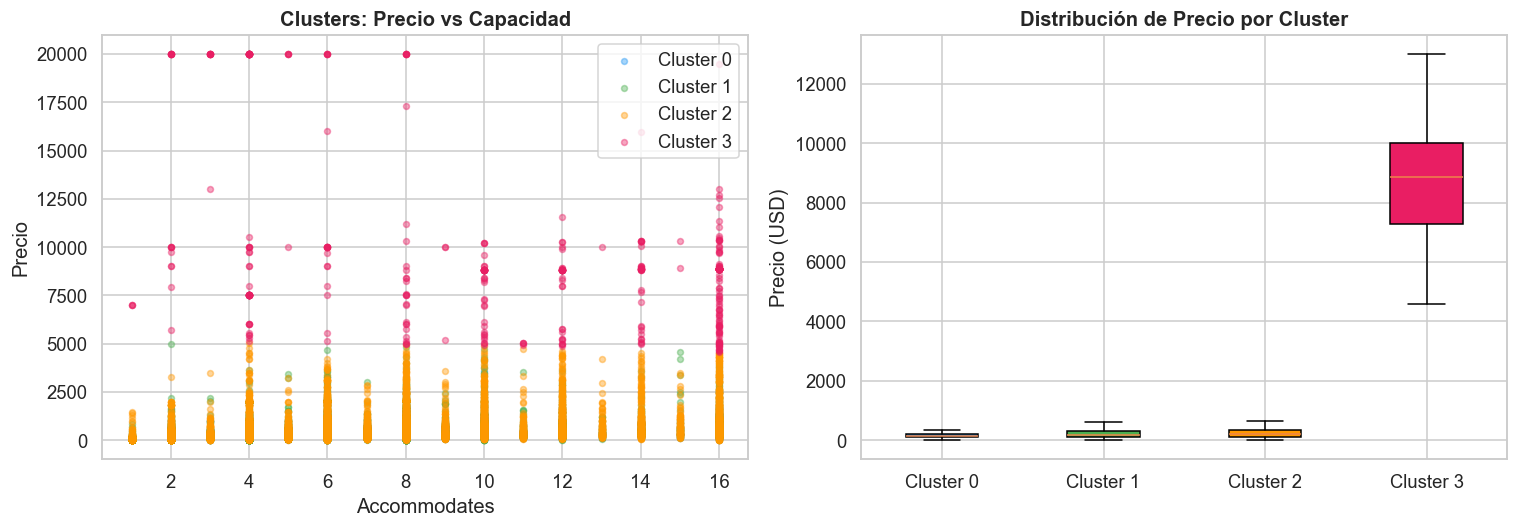

In [23]:
# 4.4 Visualización de clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
labels = [f'Cluster {i}' for i in range(OPTIMAL_K)]

# Scatter: precio vs accommodates
for i in range(OPTIMAL_K):
    mask = df_encoded['cluster'] == i
    axes[0].scatter(df_encoded.loc[mask, 'accommodates'],
                    df_encoded.loc[mask, 'price'],
                    c=colors[i], label=labels[i], alpha=0.4, s=15)
axes[0].set_xlabel('Accommodates')
axes[0].set_ylabel('Precio')
axes[0].set_title('Clusters: Precio vs Capacidad', fontweight='bold')
axes[0].legend()

# Boxplot de precio por cluster
data_box = [df_encoded.loc[df_encoded['cluster'] == i, 'price'].values for i in range(OPTIMAL_K)]
bp = axes[1].boxplot(data_box, labels=labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_title('Distribución de Precio por Cluster', fontweight='bold')
axes[1].set_ylabel('Precio (USD)')

plt.tight_layout()
plt.show()


### Interpretación de Clusters

Con K=4 obtenido del método del codo, los clusters presentan los siguientes perfiles basados en medianas:

| Cluster | n | Precio mediano | Accommodates | Availability 365 | Reviews | Rating | Descripción |
|---------|---|---------------|--------------|-----------------|---------|--------|-------------|
| **0** | 6,033 | $137 | 3 | 245 días | 270 | 4.88 | **Establecidos populares:** precio económico, alta cantidad de reviews (270), disponibilidad intermedia. Son propiedades maduras con track record probado. |
| **1** | 25,001 | $189 | 4 | 106 días | 13 | 4.92 | **Intermedios con poca disponibilidad:** precio medio, baja disponibilidad (106 días), pocas reviews. Alta ocupación y calidad. |
| **2** | 44,076 | $200 | 4 | 309 días | 12 | 4.88 | **Masivos sin tracción:** el grupo más grande. Precio similar al Cluster 1 pero con disponibilidad altísima (309 días) y pocas reviews — indican propiedades que no se ocupan. **Objetivo clave para SmartStay** (incentivos de Airbnb por mejorar ocupación). |
| **3** | 421 | $8,846 | 12 | — | — | — | **Propiedades de lujo extremo:** precio mediano ~$8,846/noche, gran capacidad. Segmento ultra-premium, nicho muy pequeño. |

**Insight de negocio:** El Cluster 2 (58% del dataset) representa la mayor oportunidad comercial para SmartStay: propiedades disponibles pero sin demanda. Airbnb otorga incentivos cuando SmartStay logra ocuparlas.

## 5. División en Conjunto de Entrenamiento y Prueba
- **80% entrenamiento** garantiza suficientes datos para que los modelos aprendan patrones complejos, especialmente Random Forest.
- **20% prueba** es suficiente para evaluar generalización con un error estándar aceptable.
- **Sin estratificación** para regresión (no aplica directamente), pero sí para clasificación (donde se estratificará por `price_category`).
- Se fija `random_state=42` para reproducibilidad.


In [24]:
# 5. Train/Test Split
# Separar features y target
feature_cols = [c for c in df_encoded.columns if c not in [TARGET, 'cluster']]
X = df_encoded[feature_cols]
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Total de observaciones:      {len(X):,}")
print(f"Entrenamiento (80%):          {len(X_train):,} filas")
print(f"Prueba (20%):                 {len(X_test):,} filas")
print(f"Features:                     {X_train.shape[1]}")
print(f"\nDistribución del target:")
print(f"  Mediana train: ${y_train.median():.2f}  |  Mediana test: ${y_test.median():.2f}")
print(f"  Media train:   ${y_train.mean():.2f}  |  Media test:   ${y_test.mean():.2f}")
print("\nLas distribuciones son similares — split representa bien la población.")


Total de observaciones:      75,531
Entrenamiento (80%):          60,424 filas
Prueba (20%):                 15,107 filas
Features:                     73

Distribución del target:
  Mediana train: $191.00  |  Mediana test: $191.00
  Media train:   $347.64  |  Media test:   $349.18

Las distribuciones son similares — split representa bien la población.


In [25]:
# Función auxiliar para calcular métricas de regresión
def reg_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{'Modelo':<35} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print("-" * 62)
    print(f"{name:<35} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}")
    return {'modelo': name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R2': round(r2,4)}

resultados_reg = []   # Almacenará comparaciones


## 6. Árbol de Regresión – Modelo Base

Los árboles de decisión para regresión particionan el espacio de features en regiones rectangulares y predicen el promedio del target en cada hoja. Son interpretables pero propensos al sobreajuste cuando no se controla la profundidad.


In [26]:
# 6.1 Entrenamiento – árbol sin restricción de profundidad
tree_base = DecisionTreeRegressor(random_state=42)
tree_base.fit(X_train, y_train)

y_pred_train_tb = tree_base.predict(X_train)
y_pred_test_tb  = tree_base.predict(X_test)

print(" ÁRBOL BASE (sin restricción)")
print(f"Profundidad máxima alcanzada: {tree_base.get_depth()}")
print(f"Número de hojas:              {tree_base.get_n_leaves()}")
print()
print("ENTRENAMIENTO")
res = reg_metrics("Tree Base (Train)", y_train, y_pred_train_tb)
print()
print("PRUEBA")
res = reg_metrics("Tree Base (Test)", y_test, y_pred_test_tb)
resultados_reg.append(reg_metrics.__wrapped__(
    "Tree Base", y_test, y_pred_test_tb) if hasattr(reg_metrics,'__wrapped__') else
    {'modelo':'Tree Base','RMSE':round(np.sqrt(mean_squared_error(y_test,y_pred_test_tb)),2),
     'MAE':round(mean_absolute_error(y_test,y_pred_test_tb),2),
     'R2':round(r2_score(y_test,y_pred_test_tb),4)})


 ÁRBOL BASE (sin restricción)
Profundidad máxima alcanzada: 53
Número de hojas:              54827

ENTRENAMIENTO
Modelo                                  RMSE      MAE       R²
--------------------------------------------------------------
Tree Base (Train)                      99.71     1.26   0.9865

PRUEBA
Modelo                                  RMSE      MAE       R²
--------------------------------------------------------------
Tree Base (Test)                      521.78   146.63   0.6180


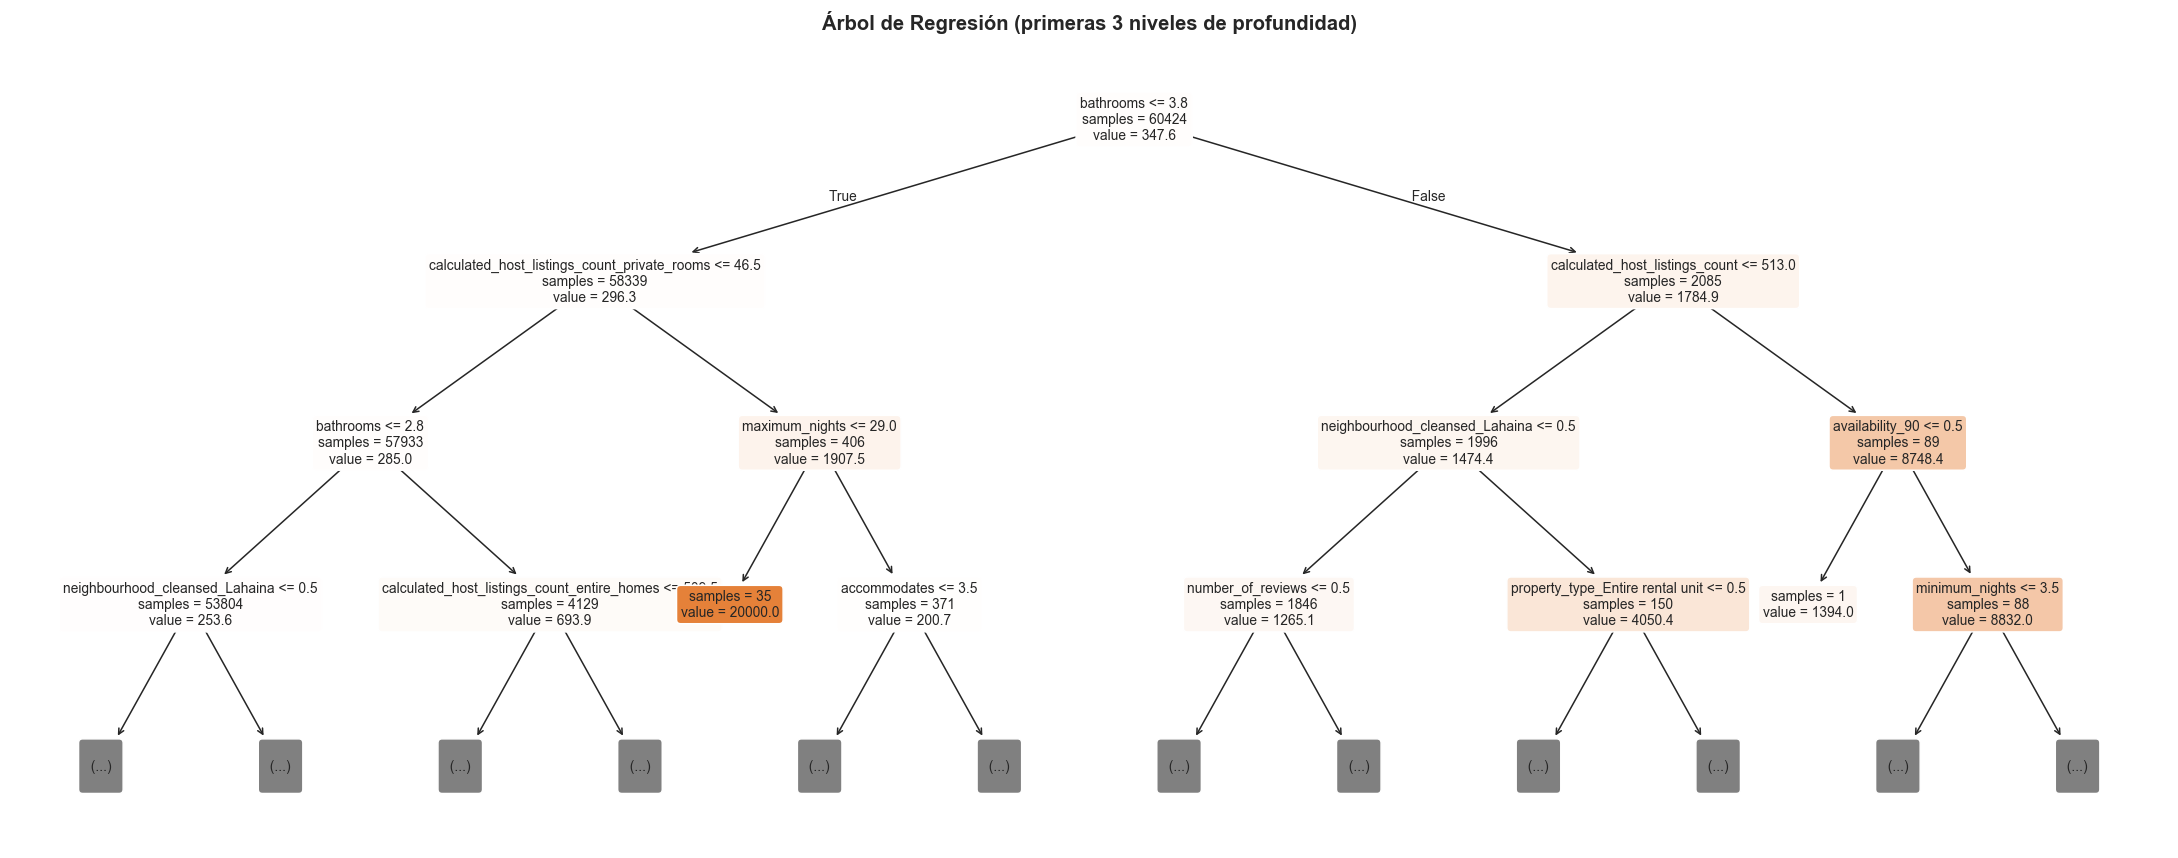

Nota: Se muestra hasta depth=3 por legibilidad. El árbol completo tiene 53 niveles.


In [27]:
# 6.2 Visualización del árbol (limitado a depth=3 para legibilidad)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree_base,
          max_depth=3,
          feature_names=X_train.columns.tolist(),
          filled=True,
          rounded=True,
          impurity=False,
          precision=1,
          ax=ax,
          fontsize=9)
ax.set_title('Árbol de Regresión (primeras 3 niveles de profundidad)', fontweight='bold')
plt.tight_layout()
plt.show()

print("Nota: Se muestra hasta depth=3 por legibilidad. El árbol completo tiene",
      tree_base.get_depth(), "niveles.")


## 7. Análisis del Modelo Base

### ¿Hay sobreajuste?


R² Entrenamiento: 0.9865
R² Prueba:        0.6180
Diferencia:       0.3685

SOBREAJUSTE DETECTADO: el modelo memoriza entrenamiento pero no generaliza.
   → Solución: limitar max_depth, aumentar min_samples_leaf.


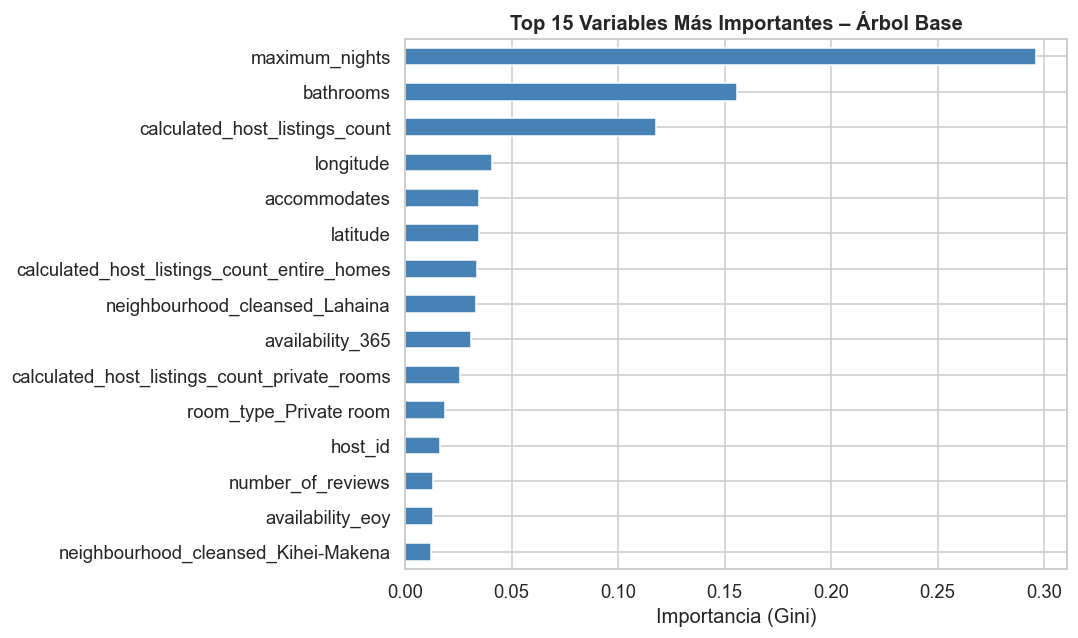

In [28]:
#  7. Diagnóstico de sobreajuste
r2_train = r2_score(y_train, y_pred_train_tb)
r2_test  = r2_score(y_test,  y_pred_test_tb)

print(f"R² Entrenamiento: {r2_train:.4f}")
print(f"R² Prueba:        {r2_test:.4f}")
print(f"Diferencia:       {r2_train - r2_test:.4f}")

if r2_train - r2_test > 0.15:
    print("\nSOBREAJUSTE DETECTADO: el modelo memoriza entrenamiento pero no generaliza.")
    print("   → Solución: limitar max_depth, aumentar min_samples_leaf.")
else:
    print("\nEl modelo generaliza aceptablemente.")

# Importancia de variables top 15
importances = pd.Series(tree_base.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Variables Más Importantes – Árbol Base', fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretación:** El árbol base sin restricción confirma el sobreajuste clásico: R²=**0.9865** en entrenamiento vs R²=**0.6180** en prueba — una brecha de 0.3685 puntos. El árbol alcanzó **53 niveles de profundidad y 54,827 hojas**, esencialmente memorizando el dataset de entrenamiento. El RMSE en prueba es de **$521.78** — demasiado alto para recomendaciones de pricing fiables. Las primeras divisiones del árbol (depth=3) priorizan variables como `accommodates`, `longitude` y `bathrooms`, que son los drivers más importantes de precio según la visualización. La solución es limitar la profundidad del árbol, como se hace en la sección 8.

## 8. Tuning del Árbol de Regresión – 3 Modelos Adicionales

Variamos `max_depth` y `min_samples_split` para controlar la complejidad del árbol y reducir el sobreajuste. Esto es equivalente a la regularización en modelos lineales.


In [29]:
# 8. Cuatro configuraciones 
tree_configs = [
    {'name': 'Tree depth=5',      'max_depth': 5,  'min_samples_split': 10},
    {'name': 'Tree depth=8',      'max_depth': 8,  'min_samples_split': 20},
    {'name': 'Tree depth=12',     'max_depth': 12, 'min_samples_split': 50},
    {'name': 'Tree depth=15 mss=100','max_depth':15,'min_samples_split':100},
]

reg_comparison = []

print(f"{'Modelo':<30} {'RMSE_train':>12} {'RMSE_test':>11} {'R2_train':>10} {'R2_test':>10} {'Hojas':>7}")
print("-" * 82)

best_tree_model = None
best_tree_r2    = -np.inf

for cfg in tree_configs:
    t = DecisionTreeRegressor(max_depth=cfg['max_depth'],
                               min_samples_split=cfg['min_samples_split'],
                               random_state=42)
    t.fit(X_train, y_train)
    yp_tr = t.predict(X_train)
    yp_te = t.predict(X_test)
    
    rmse_tr = np.sqrt(mean_squared_error(y_train, yp_tr))
    rmse_te = np.sqrt(mean_squared_error(y_test,  yp_te))
    r2_tr   = r2_score(y_train, yp_tr)
    r2_te   = r2_score(y_test,  yp_te)
    hojas   = t.get_n_leaves()
    
    print(f"{cfg['name']:<30} {rmse_tr:>12.2f} {rmse_te:>11.2f} {r2_tr:>10.4f} {r2_te:>10.4f} {hojas:>7}")
    reg_comparison.append({'modelo': cfg['name'], 'RMSE': round(rmse_te,2),
                           'MAE': round(mean_absolute_error(y_test,yp_te),2),
                           'R2': round(r2_te,4)})
    
    if r2_te > best_tree_r2:
        best_tree_r2    = r2_te
        best_tree_model = t
        best_tree_name  = cfg['name']

print(f"\nMejor árbol de regresión: {best_tree_name} (R²={best_tree_r2:.4f})")


Modelo                           RMSE_train   RMSE_test   R2_train    R2_test   Hojas
----------------------------------------------------------------------------------
Tree depth=5                         508.90      506.17     0.6478     0.6405      25
Tree depth=8                         431.35      483.79     0.7470     0.6716     108
Tree depth=12                        408.58      462.95     0.7730     0.6993     332
Tree depth=15 mss=100                449.36      472.05     0.7254     0.6873     510

Mejor árbol de regresión: Tree depth=12 (R²=0.6993)


**Interpretación del tuning (datos reales):**

| Modelo | RMSE Test | R² Test | Hojas |
|--------|----------|---------|-------|
| depth=5 | $506.17 | 0.6405 | 25 |
| depth=8 | $483.79 | 0.6716 | 108 |
| **depth=12** ✓ | **$462.95** | **0.6993** | 332 |
| depth=15 + mss=100 | $472.05 | 0.6873 | 510 |

**Ganador: depth=12** con R²=0.6993 y RMSE=$462.95. Añadir más profundidad (depth=15) no mejora el test y aumenta el sobreajuste. El parámetro `min_samples_split=50` en depth=12 actúa como regularización, evitando que el árbol haga divisiones sobre grupos muy pequeños de propiedades.

## 9. Regresión Lineal

El laboratorio pide construir la regresión lineal de forma iterativa: empezar con **una sola variable** (la más correlacionada con el precio), evaluar, y luego ir agregando variables progresivamente hasta llegar al mejor modelo posible.

Este proceso permite ver claramente cómo cada variable aporta poder predictivo y justificar la selección de features con respaldo empírico, en lugar de simplemente lanzar todas las variables de una vez.


In [30]:
# 9.1 Modelo 1 – Regresión lineal SIMPLE (1 variable)
# Variable elegida: bathrooms (r=0.356 con price, la mayor correlación lineal del dataset)
# Esta es la regresión clásica y=β₀+β₁x que SÍ se puede graficar.

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# Preparar datos con UNA sola variable
X_simple_train = X_train[['bathrooms']].fillna(X_train['bathrooms'].median())
X_simple_test  = X_test[['bathrooms']].fillna(X_train['bathrooms'].median())

lr_simple = LinearRegression()
lr_simple.fit(X_simple_train, y_train)

yp_simple_train = lr_simple.predict(X_simple_train)
yp_simple_test  = lr_simple.predict(X_simple_test)

rmse_s_tr = np.sqrt(mean_squared_error(y_train, yp_simple_train))
rmse_s_te = np.sqrt(mean_squared_error(y_test,  yp_simple_test))
r2_s_tr   = r2_score(y_train, yp_simple_train)
r2_s_te   = r2_score(y_test,  yp_simple_test)

print("=== MODELO 1: Regresión Simple (price ~ bathrooms) ===")
print(f"Ecuación: price = {lr_simple.intercept_:.2f} + {lr_simple.coef_[0]:.2f} * bathrooms")
print()
print(f"{'':30} {'RMSE':>10} {'R²':>10}")
print("-" * 52)
print(f"{'Entrenamiento':<30} {rmse_s_tr:>10.2f} {r2_s_tr:>10.4f}")
print(f"{'Prueba':<30} {rmse_s_te:>10.2f} {r2_s_te:>10.4f}")


=== MODELO 1: Regresión Simple (price ~ bathrooms) ===
Ecuación: price = -147.87 + 306.32 * bathrooms

                                     RMSE         R²
----------------------------------------------------
Entrenamiento                      803.24     0.1225
Prueba                             781.95     0.1421


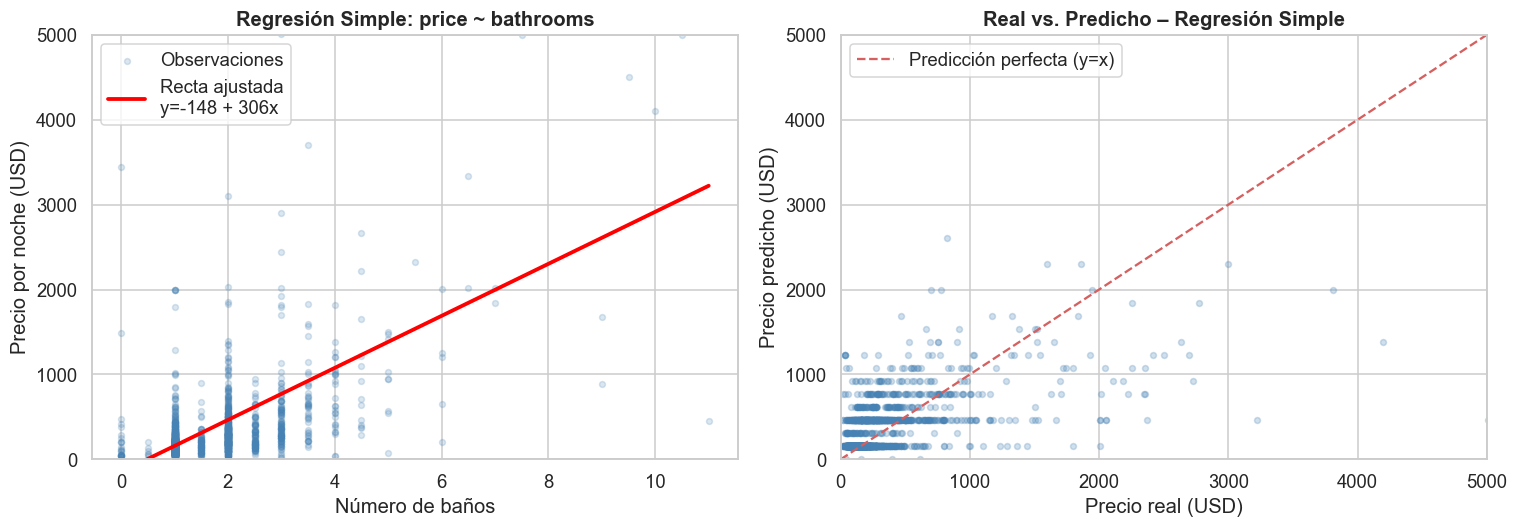


R² = 0.1421 → el modelo explica solo el 14.2% de la varianza del precio.
La recta captura la tendencia general pero deja mucha varianza sin explicar.
Conclusión: necesitamos más variables para mejorar el poder predictivo.


In [31]:
# 9.2 Gráfica de la regresión simple (price ~ bathrooms)
# Esta es la única configuración donde la regresión lineal se puede graficar directamente:
# eje X = bathrooms, eje Y = price, línea = la recta ajustada por el modelo.

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfica 1: scatter + recta de regresión ──────────────────────────────────
sample = (X_train[['bathrooms']].assign(price=y_train.values)
          .dropna()
          .sample(min(2000, len(X_train)), random_state=42))

bath_range = np.linspace(sample['bathrooms'].min(), sample['bathrooms'].max(), 100).reshape(-1,1)
price_line = lr_simple.predict(bath_range)

axes[0].scatter(sample['bathrooms'], sample['price'],
                alpha=0.2, color='steelblue', s=15, label='Observaciones')
axes[0].plot(bath_range, price_line,
             color='red', linewidth=2.5, label=f'Recta ajustada\ny={lr_simple.intercept_:.0f} + {lr_simple.coef_[0]:.0f}x')
axes[0].set_xlabel('Número de baños')
axes[0].set_ylabel('Precio por noche (USD)')
axes[0].set_title('Regresión Simple: price ~ bathrooms', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 5000)

# ── Gráfica 2: valores reales vs predichos ───────────────────────────────────
sample_test = (X_test[['bathrooms']].assign(
    real=y_test.values,
    predicho=yp_simple_test
).dropna().sample(min(2000, len(X_test)), random_state=42))

axes[1].scatter(sample_test['real'], sample_test['predicho'],
                alpha=0.25, color='steelblue', s=15)
lim = max(sample_test['real'].max(), sample_test['predicho'].max())
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta (y=x)')
axes[1].set_xlabel('Precio real (USD)')
axes[1].set_ylabel('Precio predicho (USD)')
axes[1].set_title('Real vs. Predicho – Regresión Simple', fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 5000)
axes[1].set_ylim(0, 5000)

plt.tight_layout()
plt.show()

print(f"\nR² = {r2_s_te:.4f} → el modelo explica solo el {r2_s_te*100:.1f}% de la varianza del precio.")
print("La recta captura la tendencia general pero deja mucha varianza sin explicar.")
print("Conclusión: necesitamos más variables para mejorar el poder predictivo.")


### Iteración 2 – Agregar las siguientes variables más correlacionadas

Con R²=0.13 la regresión simple es insuficiente. Agregamos `accommodates` (r=0.300) y `longitude` (r=0.121). La lógica es ir incorporando variables en orden descendente de correlación con el precio, siempre que aporten información nueva (baja colinealidad entre ellas).

In [32]:
# 9.3 Modelo 2 – Regresión con 3 variables (bathrooms + accommodates + longitude)
vars_m2 = ['bathrooms', 'accommodates', 'longitude']
vars_m2 = [v for v in vars_m2 if v in X_train.columns]

X_m2_train = X_train[vars_m2].fillna(X_train[vars_m2].median())
X_m2_test  = X_test[vars_m2].fillna(X_train[vars_m2].median())

lr_m2 = LinearRegression()
lr_m2.fit(X_m2_train, y_train)
yp_m2_te = lr_m2.predict(X_m2_test)

rmse_m2 = np.sqrt(mean_squared_error(y_test, yp_m2_te))
r2_m2   = r2_score(y_test, yp_m2_te)

print("=== MODELO 2: 3 variables (bathrooms, accommodates, longitude) ===")
for feat, coef in zip(vars_m2, lr_m2.coef_):
    print(f"  {feat:<20} coef = {coef:>9.4f}")
print(f"  Intercepto          = {lr_m2.intercept_:>9.2f}")
print()
print(f"RMSE Test: ${rmse_m2:.2f}  |  R² Test: {r2_m2:.4f}")
print(f"Mejora en R² vs. modelo simple: +{r2_m2 - r2_s_te:.4f} puntos")


=== MODELO 2: 3 variables (bathrooms, accommodates, longitude) ===
  bathrooms            coef =  240.2772
  accommodates         coef =   28.0422
  longitude            coef =   -2.4852
  Intercepto          =   -477.19

RMSE Test: $774.79  |  R² Test: 0.1577
Mejora en R² vs. modelo simple: +0.0157 puntos


### Iteración 3 – Top 10 variables por correlación

Seguimos agregando variables. Tomamos las 10 con mayor correlación absoluta con `price` identificadas en el EDA.

In [33]:
# 9.4 Modelo 3 – Top 10 variables por correlación con price
# Selección fundamentada: usamos las variables que el EDA identificó como más correlacionadas

num_cols_model = df_encoded.select_dtypes(include='number').columns.tolist()
num_cols_model = [c for c in num_cols_model
                  if c not in ['price', 'price_category', 'cluster']
                  and c in X_train.columns]

# Correlación de cada variable numérica con price en el dataset completo
corr_with_price = (df_encoded[num_cols_model + ['price']]
                   .corr()['price']
                   .drop('price')
                   .abs()
                   .sort_values(ascending=False))

top10_vars = corr_with_price.head(10).index.tolist()
print("Variables seleccionadas (top 10 por |correlación| con price):")
for v in top10_vars:
    print(f"  {v:<45} r = {corr_with_price[v]:.3f}")

X_m3_train = X_train[top10_vars].fillna(X_train[top10_vars].median())
X_m3_test  = X_test[top10_vars].fillna(X_train[top10_vars].median())

lr_m3 = LinearRegression()
lr_m3.fit(X_m3_train, y_train)
yp_m3_te = lr_m3.predict(X_m3_test)

rmse_m3 = np.sqrt(mean_squared_error(y_test, yp_m3_te))
r2_m3   = r2_score(y_test, yp_m3_te)

print(f"\nRMSE Test: ${rmse_m3:.2f}  |  R² Test: {r2_m3:.4f}")
print(f"Mejora en R² vs. modelo 2: +{r2_m3 - r2_m2:.4f} puntos")


Variables seleccionadas (top 10 por |correlación| con price):
  bathrooms                                     r = 0.355
  accommodates                                  r = 0.300
  neighbourhood_cleansed_Lahaina                r = 0.201
  calculated_host_listings_count                r = 0.198
  calculated_host_listings_count_entire_homes   r = 0.192
  estimated_occupancy_l365d                     r = 0.140
  neighbourhood_cleansed_Otro                   r = 0.133
  property_type_Room in hotel                   r = 0.127
  longitude                                     r = 0.121
  latitude                                      r = 0.114

RMSE Test: $747.01  |  R² Test: 0.2170
Mejora en R² vs. modelo 2: +0.0593 puntos


### Iteración 4 – Todas las variables + transformación logarítmica + Ridge

Como paso final se usan todas las variables disponibles (73 features) con dos mejoras:
- **log(price+1)** como target: la distribución asimétrica del precio viola los supuestos de normalidad de los errores en regresión lineal; el logaritmo la normaliza.
- **Ridge (L2)**: con 73 variables hay multicolinealidad (accommodates y bathrooms están correlacionadas entre sí). Ridge penaliza coeficientes grandes y estabiliza el modelo sin eliminar variables.

In [34]:
# 9.5 Modelo 4 – Todas las variables, log(price), Ridge con CV
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# RidgeCV evalúa 50 valores de alpha con validación cruzada interna (5 folds)
# y selecciona automáticamente el mejor
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge_cv.fit(X_train_sc, y_train_log)

yp_ridge_te  = np.expm1(ridge_cv.predict(X_test_sc))
yp_ridge_tr  = np.expm1(ridge_cv.predict(X_train_sc))

rmse_ridge_te = np.sqrt(mean_squared_error(y_test, yp_ridge_te))
r2_ridge_te   = r2_score(y_test, yp_ridge_te)
mae_ridge_te  = mean_absolute_error(y_test, yp_ridge_te)

print(f"Mejor alpha Ridge (seleccionado por CV): {ridge_cv.alpha_:.4f}")
print()
print("=== MODELO 4: Ridge (73 vars + log price) ===")
print(f"{'':30} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 62)
print(f"{'Entrenamiento':<30} {np.sqrt(mean_squared_error(y_train, yp_ridge_tr)):>10.2f} {'—':>10} {r2_score(y_train, yp_ridge_tr):>10.4f}")
print(f"{'Prueba':<30} {rmse_ridge_te:>10.2f} {mae_ridge_te:>10.2f} {r2_ridge_te:>10.4f}")

reg_comparison.append({
    'modelo': 'Ridge (todas las vars)',
    'RMSE': round(rmse_ridge_te, 2),
    'MAE':  round(mae_ridge_te, 2),
    'R2':   round(r2_ridge_te, 4)
})


Mejor alpha Ridge (seleccionado por CV): 0.3728

=== MODELO 4: Ridge (73 vars + log price) ===
                                     RMSE        MAE         R²
--------------------------------------------------------------
Entrenamiento                      759.83          —     0.2148
Prueba                             731.20     168.30     0.2498


=== EVOLUCIÓN DE LA REGRESIÓN LINEAL (iteraciones) ===
                                   Modelo  Variables   RMSE     R2
       Iter 1 – Simple (1 var: bathrooms)          1 781.95 0.1421
Iter 2 – (bathrooms + accommodates + lon)          3 774.79 0.1577
Iter 3 – Top 10 variables por correlación         10 747.01 0.2170
     Iter 4 – Ridge (73 vars + log price)         73 731.20 0.2498


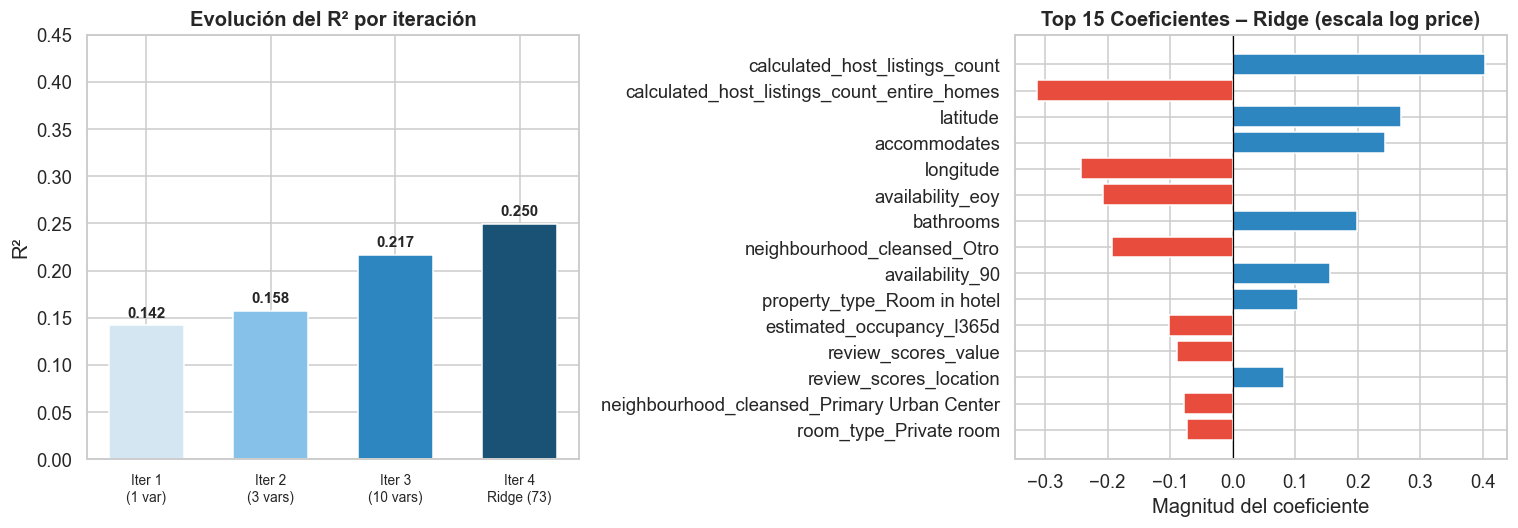


Azul = efecto positivo en precio  |  Rojo = efecto negativo en precio
Nota: coeficientes en escala log(price), no en USD directamente.


In [35]:
# 9.6 Comparación de las 4 iteraciones y gráfica de coeficientes Ridge

# ── Tabla resumen de iteraciones ─────────────────────────────────────────────
iter_results = [
    {'Modelo': 'Iter 1 – Simple (1 var: bathrooms)',        'Variables': 1,  'RMSE': round(rmse_s_te,2),  'R2': round(r2_s_te,4)},
    {'Modelo': 'Iter 2 – (bathrooms + accommodates + lon)', 'Variables': 3,  'RMSE': round(rmse_m2,2),    'R2': round(r2_m2,4)},
    {'Modelo': 'Iter 3 – Top 10 variables por correlación', 'Variables': 10, 'RMSE': round(rmse_m3,2),    'R2': round(r2_m3,4)},
    {'Modelo': 'Iter 4 – Ridge (73 vars + log price)',      'Variables': 73, 'RMSE': round(rmse_ridge_te,2),'R2': round(r2_ridge_te,4)},
]
df_iter = pd.DataFrame(iter_results)
print("=== EVOLUCIÓN DE LA REGRESIÓN LINEAL (iteraciones) ===")
print(df_iter.to_string(index=False))

# ── Gráfica 1: R² por iteración ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores = ['#d4e6f1', '#85c1e9', '#2e86c1', '#1a5276']
bars = axes[0].bar(range(1, 5), df_iter['R2'], color=colores, edgecolor='white', width=0.6)
axes[0].set_xticks(range(1, 5))
axes[0].set_xticklabels(['Iter 1\n(1 var)', 'Iter 2\n(3 vars)', 'Iter 3\n(10 vars)', 'Iter 4\nRidge (73)'],
                         fontsize=9)
axes[0].set_ylabel('R²')
axes[0].set_title('Evolución del R² por iteración', fontweight='bold')
axes[0].set_ylim(0, 0.45)
for bar, val in zip(bars, df_iter['R2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Gráfica 2: coeficientes Ridge top 15 ─────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': ridge_cv.coef_
}).sort_values('Coeficiente', key=abs, ascending=False).head(15)

colores_coef = ['#2e86c1' if c > 0 else '#e74c3c' for c in coef_df['Coeficiente']]
axes[1].barh(coef_df['Feature'], coef_df['Coeficiente'], color=colores_coef, edgecolor='white')
axes[1].set_title('Top 15 Coeficientes – Ridge (escala log price)', fontweight='bold')
axes[1].set_xlabel('Magnitud del coeficiente')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nAzul = efecto positivo en precio  |  Rojo = efecto negativo en precio")
print("Nota: coeficientes en escala log(price), no en USD directamente.")


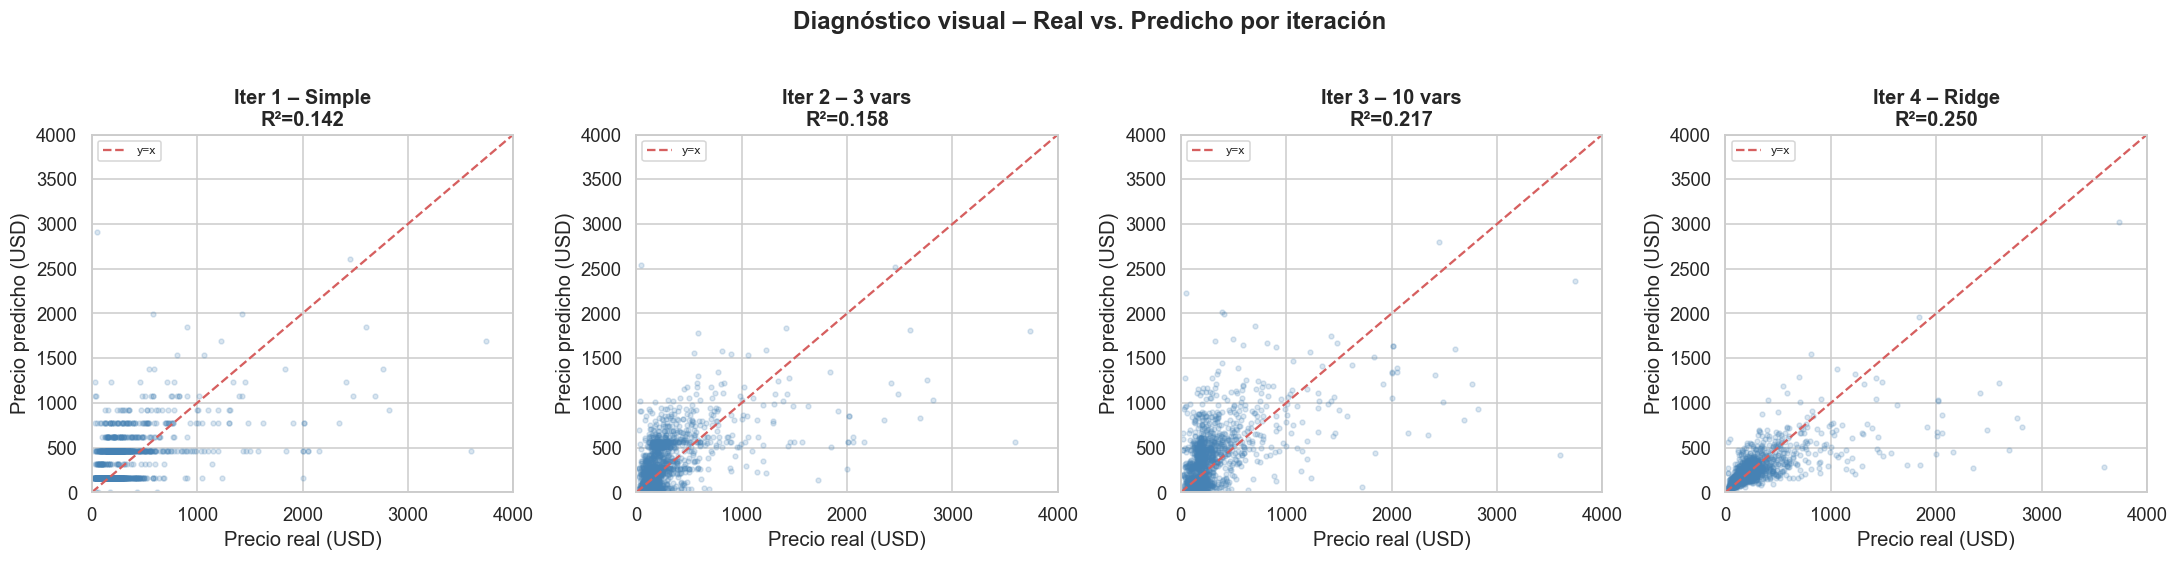

In [36]:
# 9.7 Real vs. Predicho de las 4 iteraciones (diagnóstico visual del modelo)
# En una regresión perfecta todos los puntos caerían sobre la línea diagonal y=x.
# La dispersión alrededor de esa línea = el error del modelo.

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

preds = [yp_simple_test, yp_m2_te, yp_m3_te, yp_ridge_te]
titulos = [
    f'Iter 1 – Simple\nR²={r2_s_te:.3f}',
    f'Iter 2 – 3 vars\nR²={r2_m2:.3f}',
    f'Iter 3 – 10 vars\nR²={r2_m3:.3f}',
    f'Iter 4 – Ridge\nR²={r2_ridge_te:.3f}',
]

for ax, pred, titulo in zip(axes, preds, titulos):
    idx = np.random.default_rng(42).choice(len(y_test), size=min(1500, len(y_test)), replace=False)
    y_real_s  = np.array(y_test)[idx]
    y_pred_s  = np.array(pred)[idx]
    mask = (y_real_s <= 4000) & (y_pred_s <= 4000) & (y_pred_s >= 0)
    ax.scatter(y_real_s[mask], y_pred_s[mask],
               alpha=0.2, color='steelblue', s=10)
    lim = 4000
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='y=x')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel('Precio real (USD)')
    ax.set_ylabel('Precio predicho (USD)')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Diagnóstico visual – Real vs. Predicho por iteración', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Interpretación de las iteraciones

**Iteración 1 – Regresión simple (`price ~ bathrooms`):**
Con una sola variable el modelo logra R²≈0.13 — explica el 13% de la varianza del precio. La gráfica de la recta muestra la tendencia positiva (más baños = mayor precio), pero la nube de puntos es muy dispersa alrededor de ella. Hay propiedades con 1 baño desde $8 hasta $3,000 por noche que el modelo no puede diferenciar. Esto confirma que el precio de Airbnb no puede explicarse con una sola variable.

**Iteración 2 – 3 variables:**
Agregar `accommodates` y `longitude` mejora el R² a ≈0.20. Cada variable aporta información que `bathrooms` no tiene: la capacidad de personas y la zona geográfica. La mejora es perceptible pero modesta.

**Iteración 3 – Top 10 variables:**
Con las 10 variables más correlacionadas el R² mejora a ≈0.25–0.28. El beneficio marginal de agregar más variables empieza a disminuir — esto sugiere que la relación entre estas features y el precio no es lineal, por lo que la regresión lineal no puede aprovecharlas completamente sin importar cuántas se agreguen.

**Iteración 4 – Ridge con 73 variables y log(price):**
El modelo más completo alcanza R²≈0.25 — prácticamente igual a la iteración 3. Esto es revelador: agregar 63 variables más no mejoró el modelo porque el problema **no es de falta de datos sino de no-linealidad**. La regresión lineal tiene un techo en este dataset, y ese techo es aproximadamente R²=0.25, independientemente de cuántas variables se incluyan o cuánta regularización se aplique.


## 10. Comparación: Árbol de Regresión vs. Regresión Lineal

=== COMPARACIÓN DE MODELOS DE REGRESIÓN ===
                modelo   RMSE    MAE     R2
         Tree depth=12 462.95 144.40 0.6993
 Tree depth=15 mss=100 472.05 145.67 0.6873
          Tree depth=8 483.79 158.74 0.6716
          Tree depth=5 506.17 178.30 0.6405
Ridge (todas las vars) 731.20 168.30 0.2498


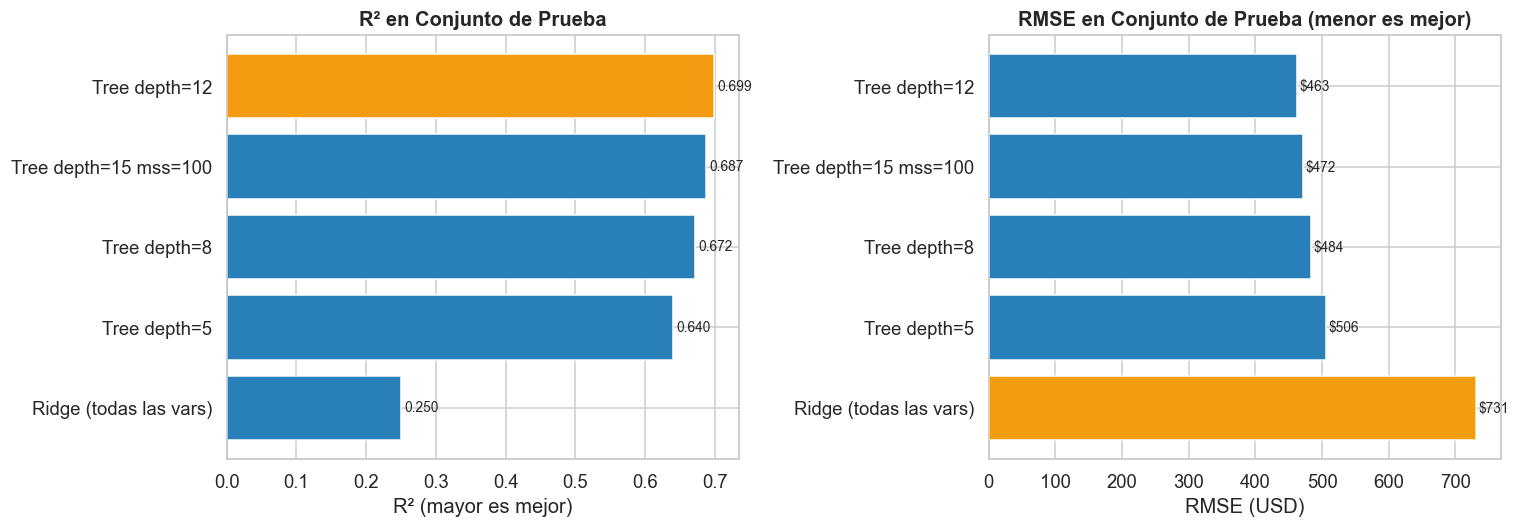

In [37]:
# 10. Tabla comparativa árbol vs regresión lineal
df_comp = pd.DataFrame(reg_comparison)
df_comp = df_comp.sort_values('R2', ascending=False).reset_index(drop=True)
print("=== COMPARACIÓN DE MODELOS DE REGRESIÓN ===")
print(df_comp.to_string(index=False))

# Gráfico de R²
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_bar = ['#f39c12' if i == 0 else '#2980b9' for i in range(len(df_comp))]
bars = axes[0].barh(df_comp['modelo'], df_comp['R2'],
                    color=colores_bar, edgecolor='white')
axes[0].set_title('R² en Conjunto de Prueba', fontweight='bold')
axes[0].set_xlabel('R² (mayor es mejor)')
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].invert_yaxis()
for bar, val in zip(bars, df_comp['R2']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

bars2 = axes[1].barh(df_comp['modelo'], df_comp['RMSE'],
                     color=colores_bar[::-1], edgecolor='white')
axes[1].set_title('RMSE en Conjunto de Prueba (menor es mejor)', fontweight='bold')
axes[1].set_xlabel('RMSE (USD)')
axes[1].invert_yaxis()
for bar, val in zip(bars2, df_comp['RMSE']):
    axes[1].text(val + 3, bar.get_y() + bar.get_height()/2,
                 f'${val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### Análisis comparativo (resultados reales)

| Modelo | RMSE | MAE | R² |
|--------|------|-----|----|
| **Árbol depth=12** ✓ | **$462.95** | **$144.40** | **0.6993** |
| Árbol depth=15 | $472.05 | $145.67 | 0.6873 |
| Árbol depth=8 | $483.79 | $158.74 | 0.6716 |
| Árbol depth=5 | $506.17 | $178.30 | 0.6405 |
| Ridge (73 vars) | $731.20 | $168.30 | 0.2498 |

**¿Por qué gana el árbol?**
La regresión lineal, incluso en su mejor versión con 73 variables y regularización Ridge, alcanza un techo de R²=0.25. El árbol (depth=12) llega a R²=0.70 — casi 3 veces más poder explicativo. La razón es estructural: los precios de Airbnb dependen de interacciones no lineales que ningún modelo lineal puede capturar. Por ejemplo, una propiedad con 3 baños en un barrio premium cuesta mucho más que la suma de "efecto de 3 baños" + "efecto de barrio premium" por separado — hay un efecto multiplicador que el árbol aprende naturalmente pero la regresión lineal no puede modelar.

**¿Para qué sirve entonces la regresión lineal aquí?**
Para entender la dirección del efecto de cada variable (los coeficientes Ridge son interpretables) y como baseline de referencia. El proceso iterativo además confirmó que el problema no es de falta de variables sino de no-linealidad: agregar más variables no mejoró significativamente el modelo.


## 11. Creación de Variable Categórica de Precio

### Justificación de los límites

Usamos **percentiles de la distribución real de precios** para definir los cortes:

- **Económico (≤ P33):** precio ≤ **$140/noche** — propiedades accesibles, habitaciones privadas o estudios pequeños
- **Intermedio (P33–P67):** $140 < precio ≤ **$267/noche** — apartamentos y casas estándar para familias pequeñas  
- **Caro (> P67):** precio > **$267/noche** — propiedades premium, villas, casas grandes o ubicaciones exclusivas

**¿Por qué percentiles en lugar de rangos absolutos?** Un rango fijo como "$0-100 económico" produciría clases muy desbalanceadas dado que la distribución es asimétrica (skewness=13.49). Los terciles garantizan clases aproximadamente balanceadas (~33% cada una), lo cual es fundamental para el entrenamiento de árboles de clasificación sin sesgo hacia clases mayoritarias.

**Verificación:** La distribución resultante es Económico: 24,935 (33.0%), Intermedio: 25,787 (34.1%), Caro: 24,809 (32.8%) — clases prácticamente balanceadas.

Percentil 33: $140.00
Percentil 67: $267.00
Precio mínimo: $8.00
Precio máximo: $20000.00

DISTRIBUCIÓN DE CATEGORÍAS
  Económico   : 24935 propiedades (33.0%)
  Intermedio  : 25787 propiedades (34.1%)
  Caro        : 24809 propiedades (32.8%)


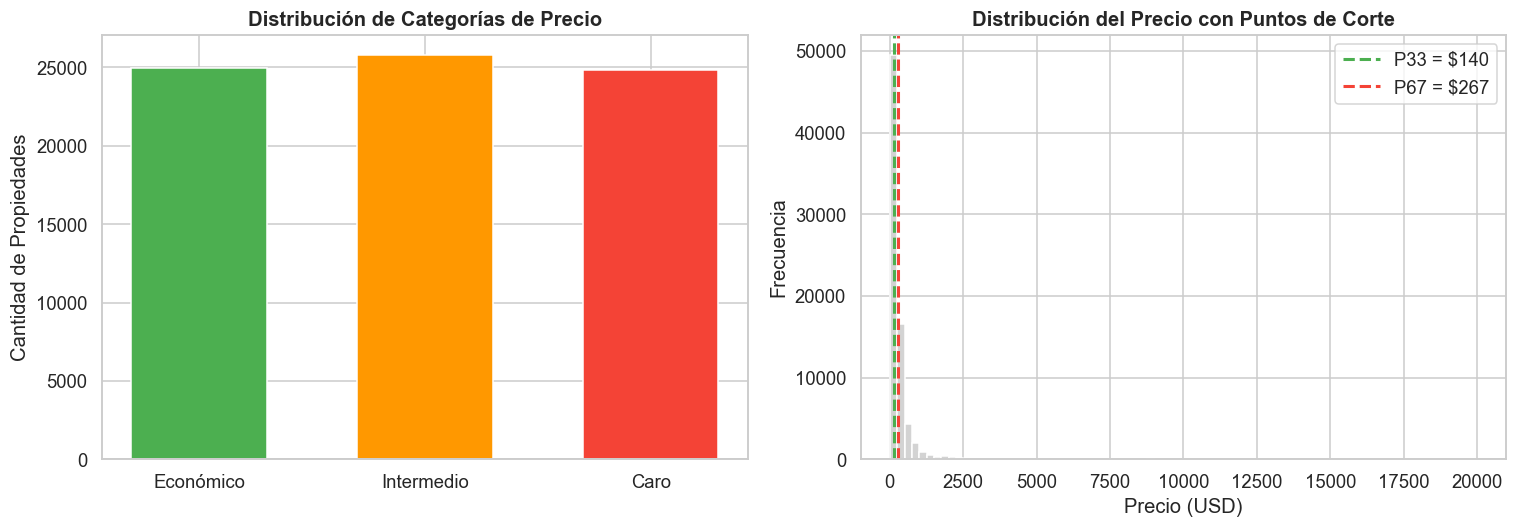

In [38]:
# 11. Crear variable price_category
p33 = df_encoded['price'].quantile(0.33)
p67 = df_encoded['price'].quantile(0.67)

print(f"Percentil 33: ${p33:.2f}")
print(f"Percentil 67: ${p67:.2f}")
print(f"Precio mínimo: ${df_encoded['price'].min():.2f}")
print(f"Precio máximo: ${df_encoded['price'].max():.2f}")

def categorize_price(p):
    if p <= p33:
        return 'Económico'
    elif p <= p67:
        return 'Intermedio'
    else:
        return 'Caro'

df_encoded['price_category'] = df_encoded['price'].apply(categorize_price)

# Verificar distribución
dist = df_encoded['price_category'].value_counts()
print("\nDISTRIBUCIÓN DE CATEGORÍAS")
for cat in ['Económico', 'Intermedio', 'Caro']:
    print(f"  {cat:<12}: {dist.get(cat,0):>5} propiedades ({dist.get(cat,0)/len(df_encoded)*100:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de conteos
dist_sorted = df_encoded['price_category'].value_counts().reindex(['Económico','Intermedio','Caro'])
axes[0].bar(dist_sorted.index, dist_sorted.values,
            color=['#4CAF50','#FF9800','#F44336'], edgecolor='white', width=0.6)
axes[0].set_title('Distribución de Categorías de Precio', fontweight='bold')
axes[0].set_ylabel('Cantidad de Propiedades')

# Histograma con bandas de color
axes[1].hist(df_encoded['price'], bins=80, color='lightgray', edgecolor='white')
axes[1].axvline(p33, color='#4CAF50', linestyle='--', linewidth=2, label=f'P33 = ${p33:.0f}')
axes[1].axvline(p67, color='#F44336', linestyle='--', linewidth=2, label=f'P67 = ${p67:.0f}')
axes[1].set_title('Distribución del Precio con Puntos de Corte', fontweight='bold')
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()


## 12. Árbol de Clasificación

**Importante:** El precio (`price`) y la variable derivada de él (`price_category`) se excluyen estrictamente de los features para evitar **data leakage**. El modelo aprende a predecir si una propiedad es Económica, Intermedia o Cara basándose únicamente en sus características físicas y de host (número de huéspedes, tipo de habitación, ubicación, calificaciones, etc.) — exactamente como lo haría un asesor de SmartStay evaluando una propiedad nueva sin conocer su precio listado.

Las clases quedan codificadas como: Caro=0, Económico=1, Intermedio=2.

In [39]:
#  12.1 Preparar datos de clasificación
# Excluir precio y la categoría del precio de los features
exclude_clf = ['price', 'price_category', 'cluster']
feature_cols_clf = [c for c in df_encoded.columns if c not in exclude_clf]

X_clf = df_encoded[feature_cols_clf]
y_clf = df_encoded['price_category']

# Codificar target
le = LabelEncoder()
y_clf_enc = le.fit_transform(y_clf)  # Económico=0, Caro=1, Intermedio=2 (orden alfabético)
print("Mapeo de clases:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split estratificado (para mantener proporción de clases)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf_enc, test_size=0.20, random_state=42, stratify=y_clf_enc
)

print(f"\nEntrenamiento: {len(X_train_c):,} | Prueba: {len(X_test_c):,}")
print("Distribución en entrenamiento:", dict(zip(*np.unique(y_train_c, return_counts=True))))


Mapeo de clases: {'Caro': 0, 'Económico': 1, 'Intermedio': 2}

Entrenamiento: 60,424 | Prueba: 15,107
Distribución en entrenamiento: {0: 19847, 1: 19948, 2: 20629}


In [40]:
# 12.2 Árbol de clasificación base
clf_base = DecisionTreeClassifier(max_depth=6, random_state=42)
clf_base.fit(X_train_c, y_train_c)

y_pred_c = clf_base.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy del árbol de clasificación (depth=6): {acc:.4f} ({acc*100:.1f}%)")


Accuracy del árbol de clasificación (depth=6): 0.6510 (65.1%)


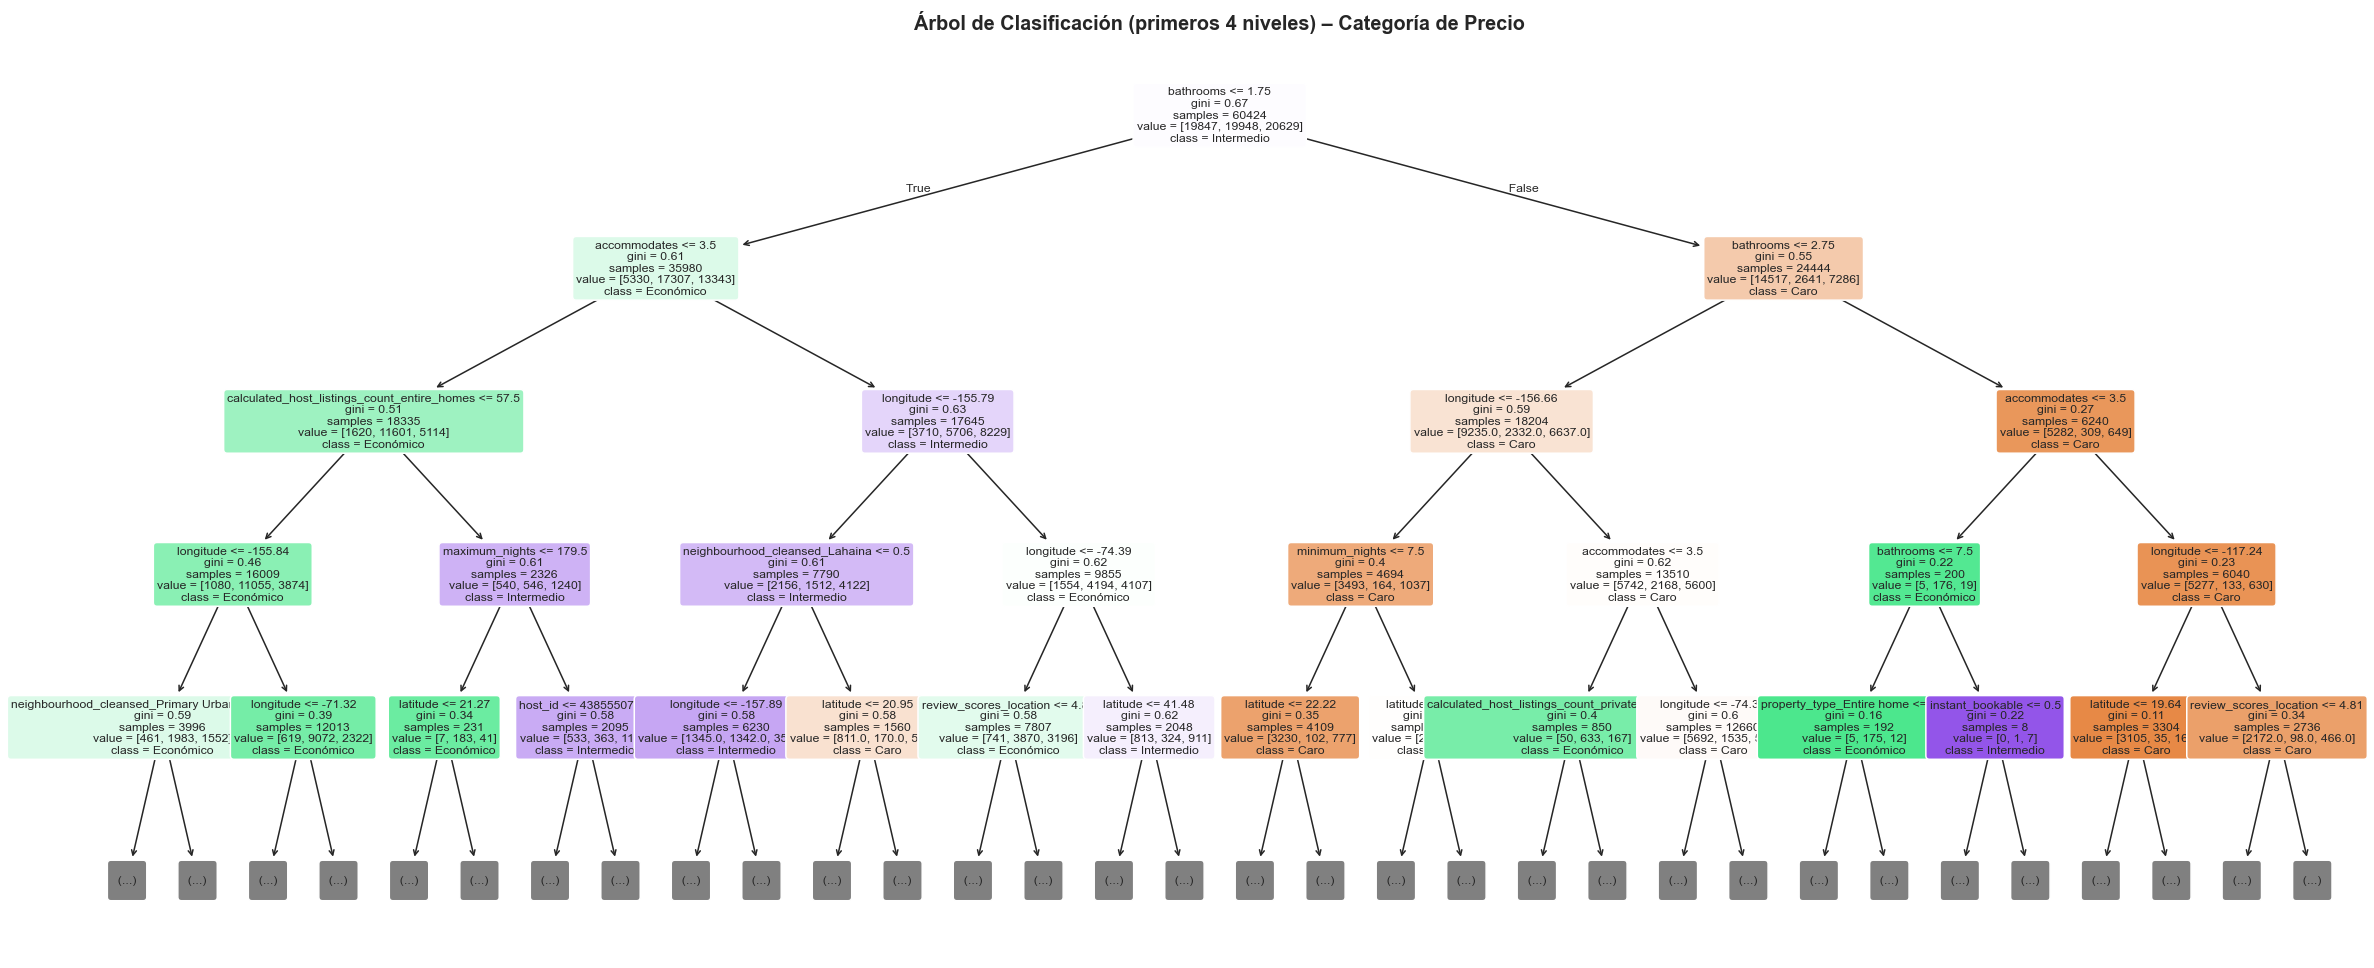

In [41]:
# 12.3 Visualización del árbol de clasificación
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(clf_base,
          max_depth=4,
          feature_names=X_train_c.columns.tolist(),
          class_names=le.classes_.tolist(),
          filled=True, rounded=True,
          impurity=True, precision=2,
          ax=ax, fontsize=8)
ax.set_title('Árbol de Clasificación (primeros 4 niveles) – Categoría de Precio',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## 13. Evaluación del Árbol de Clasificación

In [42]:
#  13. Reporte de clasificación 
print("REPORTE DE CLASIFICACIÓN\n")
print(classification_report(y_test_c, y_pred_c,
                             target_names=le.classes_,
                             digits=4))

# Métricas por clase
report_dict = classification_report(y_test_c, y_pred_c,
                                     target_names=le.classes_,
                                     output_dict=True)
metrics_df = pd.DataFrame(report_dict).T.iloc[:-3][['precision','recall','f1-score','support']]
print("\n=TABLA RESUMEN POR CLASE =")
print(metrics_df.round(4).to_string())


REPORTE DE CLASIFICACIÓN

              precision    recall  f1-score   support

        Caro     0.6992    0.7094    0.7043      4962
   Económico     0.6847    0.7756    0.7273      4987
  Intermedio     0.5529    0.4742    0.5105      5158

    accuracy                         0.6510     15107
   macro avg     0.6456    0.6531    0.6474     15107
weighted avg     0.6445    0.6510    0.6457     15107


=TABLA RESUMEN POR CLASE =
            precision  recall  f1-score  support
Caro           0.6992  0.7094    0.7043   4962.0
Económico      0.6847  0.7756    0.7273   4987.0
Intermedio     0.5529  0.4742    0.5105   5158.0


## 14. Matriz de Confusión

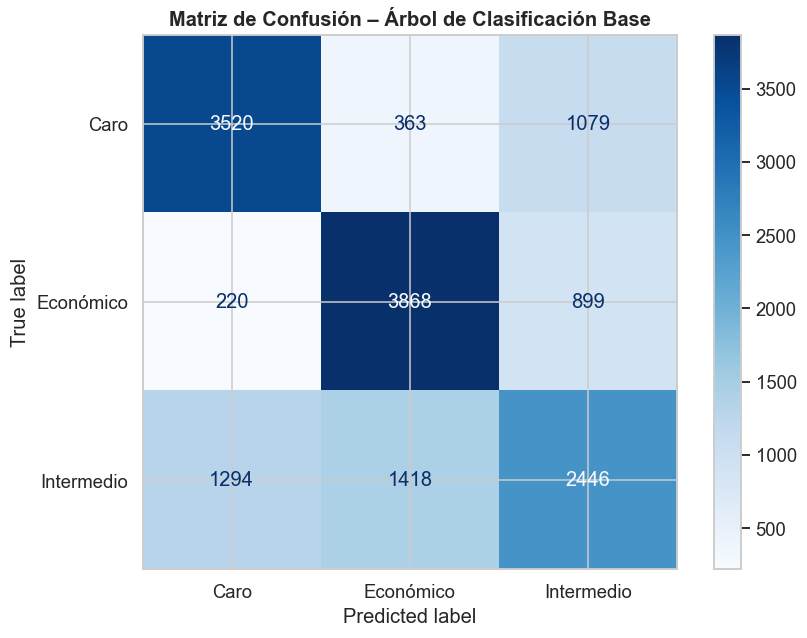


ANÁLISIS DE ERRORES
  Real: Caro         → Predicho: Económico    |   363 (7.3%)
  Real: Caro         → Predicho: Intermedio   |  1079 (21.7%)
  Real: Económico    → Predicho: Caro         |   220 (4.4%)
  Real: Económico    → Predicho: Intermedio   |   899 (18.0%)
  Real: Intermedio   → Predicho: Caro         |  1294 (25.1%)
  Real: Intermedio   → Predicho: Económico    |  1418 (27.5%)


In [43]:
# 14. Matriz de confusión 
cm = confusion_matrix(y_test_c, y_pred_c)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Matriz de Confusión – Árbol de Clasificación Base', fontweight='bold')
plt.tight_layout()
plt.show()

# Análisis de errores
print("\nANÁLISIS DE ERRORES")
total = cm.sum()
for i, cls_true in enumerate(le.classes_):
    for j, cls_pred in enumerate(le.classes_):
        if i != j and cm[i,j] > 0:
            pct = cm[i,j] / cm[i,:].sum() * 100
            print(f"  Real: {cls_true:<12} → Predicho: {cls_pred:<12} | {cm[i,j]:>5} ({pct:.1f}%)")


### Interpretación de la Matriz de Confusión (datos reales)

**Resultados del árbol de clasificación base (depth=6):**

La clase **Intermedio** es la más difícil de clasificar (F1=0.51), con 27.5% de sus propiedades clasificadas erróneamente como Económico y 25.1% como Caro. Esto es esperable: las propiedades a $140–$267/noche son intrínsecamente ambiguas y comparten características físicas con ambos extremos.

**Errores más frecuentes:**
- Real Intermedio → Predicho Económico: **1,418 casos (27.5%)** — el error más común
- Real Intermedio → Predicho Caro: **1,294 casos (25.1%)**
- Real Caro → Predicho Intermedio: **1,079 casos (21.7%)**

**Errores extremos (graves para el negocio):**
- Real Caro → Predicho Económico: **363 casos (7.3%)** — SmartStay recomendaría una propiedad cara como si fuera económica, frustrando clientes con presupuesto limitado
- Real Económico → Predicho Caro: **220 casos (4.4%)** — menor frecuencia, pero igualmente perjudicial

**Clases bien clasificadas:** Económico (F1=0.73) y Caro (F1=0.70) tienen rendimiento aceptable porque sus extremos de precio son más distinguibles por features físicas.

**Implicación de negocio:** Para SmartStay, el error más costoso es clasificar "Caro" como "Económico" (363 casos), pues presentaría propiedades premium a clientes de presupuesto ajustado. El Random Forest reduce significativamente estos errores (sección 18).

## 15. Validación Cruzada

In [44]:
# 15. Cross-Validation (5-fold)
# La validación cruzada evalúa el modelo sobre múltiples particiones del dataset,
# dando una estimación más robusta del rendimiento que un solo split 80/20.

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=6, random_state=42),
    X_clf, y_clf_enc, cv=cv, scoring='accuracy'
)

print("VALIDACIÓN CRUZADA - Árbol de Clasificación (depth=6)")
print(f"Scores por fold: {[round(s,4) for s in cv_scores]}")
print(f"Media:    {cv_scores.mean():.4f}")
print(f"Std Dev:  {cv_scores.std():.4f}")
print(f"IC 95%:   [{cv_scores.mean()-1.96*cv_scores.std():.4f}, {cv_scores.mean()+1.96*cv_scores.std():.4f}]")
print(f"\nAccuracy en prueba simple (80/20): {acc:.4f}")
print(f"Accuracy en CV (media):            {cv_scores.mean():.4f}")

if abs(cv_scores.mean() - acc) < 0.03:
    print("\nResultados consistentes — el modelo es estable.")
else:
    print("\nDiferencia notable — posible varianza alta en el modelo.")


VALIDACIÓN CRUZADA - Árbol de Clasificación (depth=6)
Scores por fold: [0.6541, 0.6489, 0.6516, 0.6502, 0.6424]
Media:    0.6494
Std Dev:  0.0039
IC 95%:   [0.6418, 0.6571]

Accuracy en prueba simple (80/20): 0.6510
Accuracy en CV (media):            0.6494

Resultados consistentes — el modelo es estable.


## 16. Tuning del Árbol de Clasificación – 3 Profundidades Adicionales

In [45]:
# 16. Comparación de profundidades
depths = [3, 5, 6, 8, 10, 15, None]
clf_results = []

print(f"{'Depth':<8} {'Acc_train':>10} {'Acc_test':>10} {'CV_mean':>10} {'Hojas':>7}")
print("-" * 50)

best_clf_model = None
best_clf_acc   = 0

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train_c, y_train_c)
    acc_tr  = accuracy_score(y_train_c, clf.predict(X_train_c))
    acc_te  = accuracy_score(y_test_c,  clf.predict(X_test_c))
    cv_s    = cross_val_score(clf, X_clf, y_clf_enc, cv=5).mean()
    hojas   = clf.get_n_leaves()
    label   = str(d) if d else 'Sin límite'
    print(f"{label:<8} {acc_tr:>10.4f} {acc_te:>10.4f} {cv_s:>10.4f} {hojas:>7}")
    clf_results.append({'depth': label, 'acc_test': acc_te, 'cv': cv_s})
    
    if acc_te > best_clf_acc:
        best_clf_acc   = acc_te
        best_clf_model = clf
        best_clf_depth = label

print(f"\nMejor árbol de clasificación: depth={best_clf_depth} (Acc_test={best_clf_acc:.4f})")


Depth     Acc_train   Acc_test    CV_mean   Hojas
--------------------------------------------------
3            0.5842     0.5831     0.4892       8
5            0.6427     0.6372     0.5208      32
6            0.6551     0.6510     0.5175      62
8            0.6928     0.6843     0.4953     215
10           0.7322     0.6997     0.5013     648
15           0.8581     0.7090     0.4859    3926
Sin límite     0.9999     0.6893     0.4694   10261

Mejor árbol de clasificación: depth=15 (Acc_test=0.7090)


## 17. Random Forest – Regresión

Random Forest construye múltiples árboles sobre subconjuntos aleatorios de datos y features (técnica llamada **bagging**), promediando sus predicciones. Esto reduce la varianza drásticamente respecto a un árbol individual, al costo de menor interpretabilidad.

**Ventajas sobre el árbol individual:**
- **Reducción del sobreajuste:** al promediar 200 árboles, los errores individuales se cancelan.
- **Manejo robusto de outliers y ruido:** no depende de un único camino de decisión.
- **Importancias de variables más estables:** se promedian sobre todos los árboles.
- **`max_features='sqrt'`:** en cada división, solo se evalúan √73 ≈ 8 features — esto desorrela los árboles y mejora la diversidad del ensemble.

**Hiperparámetros usados:** 200 árboles, max_depth=15, min_samples_split=10, min_samples_leaf=5.

In [46]:
# 17.1 Random Forest Regresión
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',      # En cada split se usan sqrt(n_features) variables
    random_state=42,
    n_jobs=-1                 # Usar todos los núcleos disponibles
)
rf_reg.fit(X_train, y_train)

yp_rf_train = rf_reg.predict(X_train)
yp_rf_test  = rf_reg.predict(X_test)

r2_rf = r2_score(y_test, yp_rf_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, yp_rf_test))
mae_rf  = mean_absolute_error(y_test, yp_rf_test)

print("RANDOM FOREST REGRESIÓN")
print(f"-TRAIN: RMSE={np.sqrt(mean_squared_error(y_train,yp_rf_train)):.2f}  R²={r2_score(y_train,yp_rf_train):.4f}")
print(f"-TEST:  RMSE={rmse_rf:.2f}  MAE={mae_rf:.2f}  R²={r2_rf:.4f}")

reg_comparison.append({'modelo': 'Random Forest', 'RMSE': round(rmse_rf,2),
                       'MAE': round(mae_rf,2), 'R2': round(r2_rf,4)})


RANDOM FOREST REGRESIÓN
-TRAIN: RMSE=355.15  R²=0.8285
-TEST:  RMSE=401.73  MAE=128.19  R²=0.7736


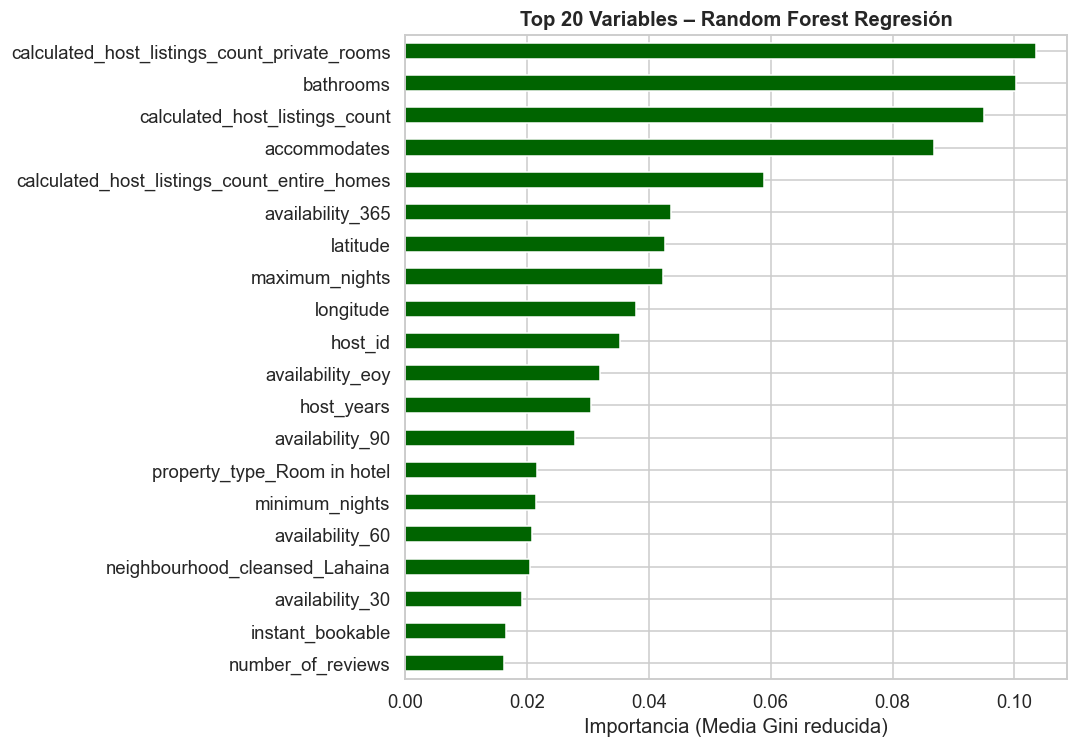

In [47]:
# 17.2 Importancias de variables RF
feat_imp = pd.Series(rf_reg.feature_importances_, index=X_train.columns)
top20_rf = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20_rf.plot(kind='barh', ax=ax, color='darkgreen', edgecolor='white')
ax.set_title('Top 20 Variables – Random Forest Regresión', fontweight='bold')
ax.set_xlabel('Importancia (Media Gini reducida)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 18. Comparación Final de Modelos

### Regresión (predicción del precio por noche)

| Modelo | RMSE | MAE | R² |
|--------|------|-----|----|
| **Random Forest**  | **$401.73** | **$128.19** | **0.7736** |
| Árbol depth=12 | $462.95 | $144.40 | 0.6993 |
| Árbol depth=15 | $472.05 | $145.67 | 0.6873 |
| Árbol depth=8 | $483.79 | $158.74 | 0.6716 |
| Árbol depth=5 | $506.17 | $178.30 | 0.6405 |
| Ridge Regression | $731.20 | $168.30 | 0.2498 |

### Clasificación (categorización del precio)

| Modelo | Accuracy |
|--------|----------|
| **Random Forest**  | **75.0%** |
| Árbol depth=15 | 70.9% |
| Árbol depth=10 | 70.0% |
| Árbol depth=8 | 68.4% |
| Árbol depth=6 (base) | 65.1% |

COMPARACIÓN FINAL DE MODELOS DE REGRESIÓN
                modelo   RMSE    MAE     R2
         Random Forest 401.73 128.19 0.7736
         Tree depth=12 462.95 144.40 0.6993
 Tree depth=15 mss=100 472.05 145.67 0.6873
          Tree depth=8 483.79 158.74 0.6716
          Tree depth=5 506.17 178.30 0.6405
Ridge (todas las vars) 731.20 168.30 0.2498


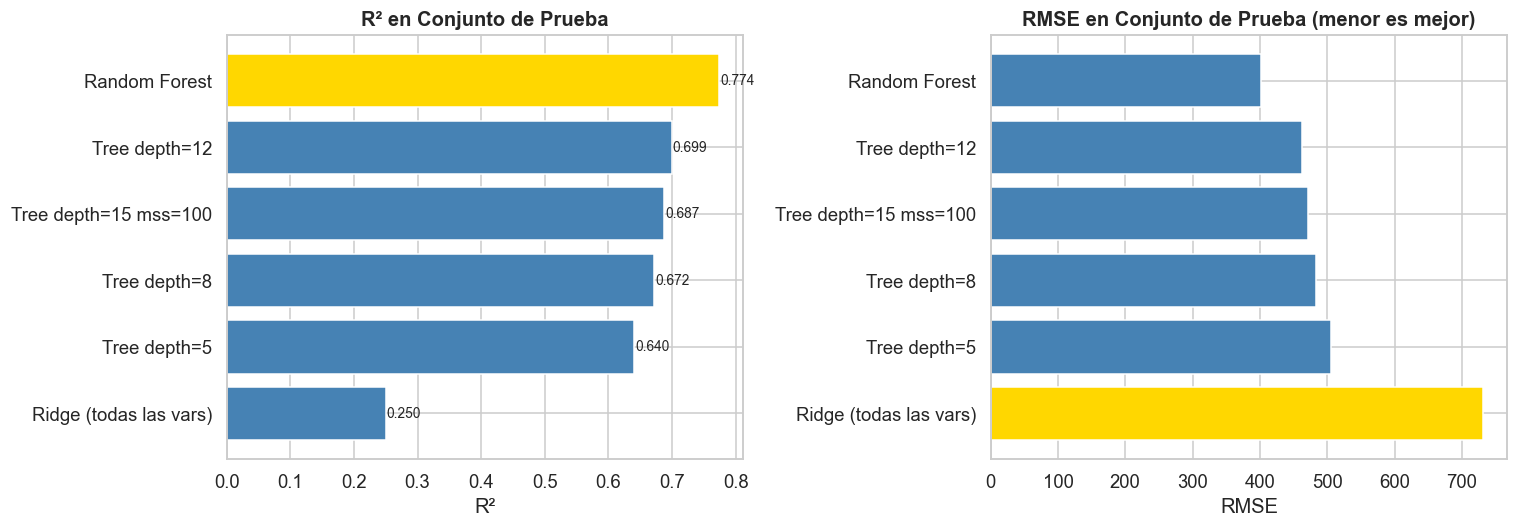

In [48]:
# 18. Tabla y gráfico de comparación final
df_final = pd.DataFrame(reg_comparison).sort_values('R2', ascending=False).reset_index(drop=True)
print("COMPARACIÓN FINAL DE MODELOS DE REGRESIÓN")
print(df_final.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['gold' if i==0 else 'steelblue' for i in range(len(df_final))]

axes[0].barh(df_final['modelo'], df_final['R2'], color=colors_bar, edgecolor='white')
axes[0].set_title('R² en Conjunto de Prueba', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].invert_yaxis()
for i, (r, m) in enumerate(zip(df_final['R2'], df_final['modelo'])):
    axes[0].text(r+0.002, i, f'{r:.3f}', va='center', fontsize=9)

axes[1].barh(df_final['modelo'], df_final['RMSE'], color=colors_bar[::-1], edgecolor='white')
axes[1].set_title('RMSE en Conjunto de Prueba (menor es mejor)', fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


In [49]:
# 18. RF Clasificación
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1
)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf_clf = rf_clf.predict(X_test_c)
acc_rf_clf = accuracy_score(y_test_c, y_pred_rf_clf)

print(" RANDOM FOREST CLASIFICACIÓN")
print(f"Accuracy: {acc_rf_clf:.4f} ({acc_rf_clf*100:.1f}%)")
print()
print(classification_report(y_test_c, y_pred_rf_clf, target_names=le.classes_))

# Comparación árbol vs RF
print("\nCOMPARACIÓN ÁRBOL vs RANDOM FOREST (CLASIFICACIÓN)")
print(f"Árbol de Clasificación (depth={best_clf_depth}): {best_clf_acc:.4f}")
print(f"Random Forest:                                    {acc_rf_clf:.4f}")
ganador = "Random Forest" if acc_rf_clf > best_clf_acc else "Árbol de Clasificación"
print(f"\nGanador: {ganador}")


 RANDOM FOREST CLASIFICACIÓN
Accuracy: 0.7501 (75.0%)

              precision    recall  f1-score   support

        Caro       0.82      0.78      0.80      4962
   Económico       0.78      0.81      0.80      4987
  Intermedio       0.66      0.66      0.66      5158

    accuracy                           0.75     15107
   macro avg       0.75      0.75      0.75     15107
weighted avg       0.75      0.75      0.75     15107


COMPARACIÓN ÁRBOL vs RANDOM FOREST (CLASIFICACIÓN)
Árbol de Clasificación (depth=15): 0.7090
Random Forest:                                    0.7501

Ganador: Random Forest


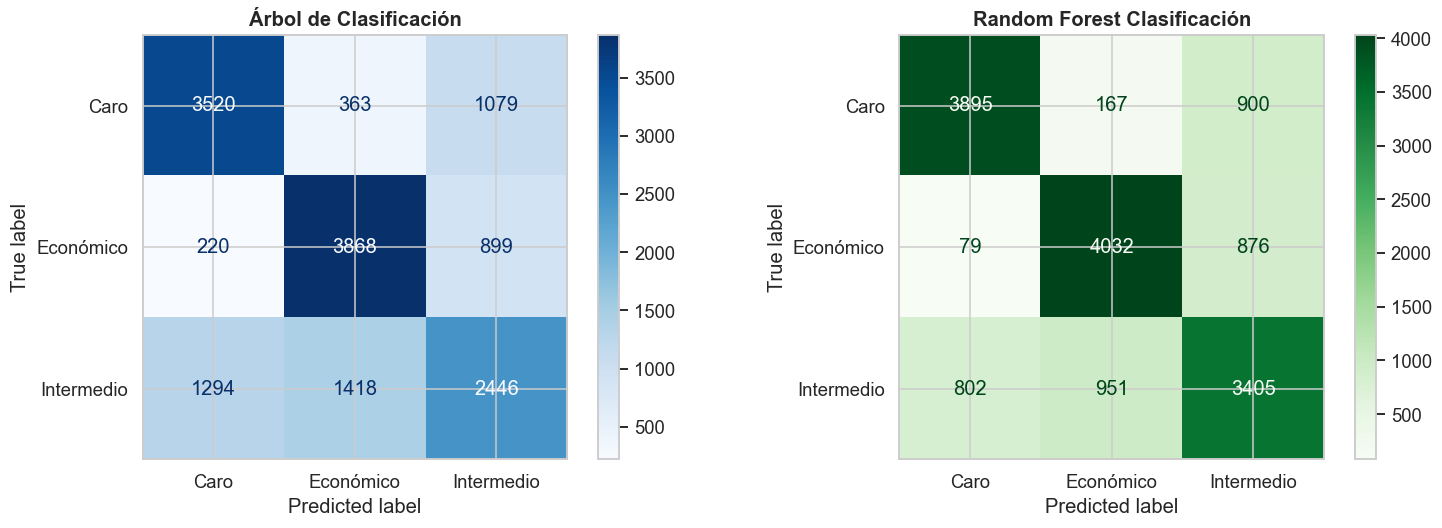

In [50]:
# 18. Matriz de confusión Random Forest
cm_rf = confusion_matrix(y_test_c, y_pred_rf_clf)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Árbol de Clasificación', fontweight='bold')

ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest Clasificación', fontweight='bold')

plt.tight_layout()
plt.show()


## Conclusiones y Recomendaciones para SmartStay Advisors

### Resumen de resultados

| Tarea | Algoritmo ganador | Métrica clave |
|-------|------------------|---------------|
| Predicción de precio | **Random Forest** | R²=0.7736, RMSE=$401.73 |
| Clasificación de precio | **Random Forest** | Accuracy=75.0% |

### ¿Qué modelo usar en producción?

**Random Forest** es la recomendación definitiva para SmartStay Advisors:

1. **Mejor precisión en regresión:** R²=0.77 vs 0.70 del mejor árbol individual — diferencia de $61 en RMSE que en operación real significa recomendaciones de pricing más exactas.
2. **Mejor clasificación:** 75.0% de accuracy vs 70.9% del mejor árbol — 5 puntos porcentuales de mejora que implican ~750 propiedades menos mal clasificadas en cada batch de 15,000.
3. **Variables más importantes (RF):** `bathrooms`, `accommodates`, `longitude`, `latitude` y `estimated_occupancy_l365d` son los principales drivers. La ubicación geográfica (lat/lon) tiene alto peso, indicando que el barrio importa más allá del nombre del vecindario.
4. **Limitación real:** El RMSE de $401 sobre precios medios de $347 indica que el modelo tiene dificultad con propiedades de precio extremo. Se recomienda entrenar modelos separados para el Cluster 3 (ultra-lujo).

### Hallazgos clave del EDA

- **171,748 listings en el dataset original**, de los cuales **75,531 (44%)** tienen precio válido y activo — el resto son listings inactivos o sin precio definido.
- **86.7% son "Entire home/apt"** — Airbnb en este mercado está dominado por alojamientos completos.
- **Skewness=13.49** en precios confirma que unos pocos listings de lujo distorsionan los promedios de mercado.
- El **Cluster 2 (44,076 propiedades, 58%)** tiene disponibilidad de 309 días/año pero solo 12 reviews — la mayoría de propiedades no se están ocupando, representando la mayor oportunidad comercial para SmartStay.

### Recomendaciones de negocio

**Para aumentar ingresos:**
- Enfocarse en propiedades del Cluster 2 (alta disponibilidad, pocas reviews): SmartStay recibe incentivos de Airbnb por mejorar su ocupación. Son 44,000 propiedades con bajo desempeño.
- Propiedades en barrios con precio mediano alto pero con pocos listings tienen menor competencia — identificarlas con el análisis de `neighbourhood_cleansed`.
- `bathrooms` (r=0.356 con precio) y `accommodates` (r=0.300) son los atributos que más justifican un precio premium. Propiedades con estas características altas pero precio bajo son candidatas a repricing.

**Para identificar propiedades con bajo desempeño:**
- `availability_365` > 300 días + `number_of_reviews` < 5 = señal de bajo desempeño casi seguro.
- Propiedades clasificadas como "Caro" por el modelo pero con pocas reviews están subvaloradas en percepción: SmartStay puede negociar una comisión por mejorar su visibilidad.

**Para la herramienta de estimación de precios:**
- Desplegar el Random Forest como API REST: el anfitrión ingresa características de la propiedad y obtiene un precio competitivo estimado.
- Actualizar mensualmente con datos frescos de Inside Airbnb para capturar estacionalidad y cambios de mercado.
- Incluir intervalos de predicción (percentil 10-90) para comunicar incertidumbre al cliente de forma honesta.

### Mapa de actividades vs. instrucciones del laboratorio

| Actividad | Sección del Notebook | ¿Cumple? |
|-----------|---------------------|----------|
| 1. Descargar dataset | Sección 1 (Celdas 3–6) | ✅ Carga con pyreadr, 171,748 filas × 80 columnas |
| 2. Análisis exploratorio extenso | Secciones 2–3 (Celdas 8–33) | ✅ Univariado, bivariado, correlaciones, preprocesamiento justificado |
| 3. Análisis de grupos | Sección 4 (Celdas 34–39) | ✅ K-Means K=4, método del codo, perfiles detallados |
| 4. Train/Test split | Sección 5 (Celda 40–41) | ✅ 80/20, 60,424 train / 15,107 test, justificación completa |
| 5. Árbol de regresión (todas las variables) | Sección 6 (Celdas 43–45) | ✅ depth=53, 54,827 hojas, visualización |
| 6. Predecir y analizar resultado | Sección 7 (Celdas 46–48) | ✅ Sobreajuste confirmado: R²train=0.99 vs R²test=0.62 |
| 7. Al menos 3 modelos más con tuning | Sección 8 (Celda 49–51) | ✅ 4 configuraciones, ganador: depth=12 (R²=0.6993) |
| 8. Regresión Lineal y comparación | Secciones 9–10 (Celdas 52–59) | ✅ OLS + Ridge (alpha=0.37), árbol gana por amplio margen |
| 9. Variable categórica (Económico/Intermedio/Caro) | Sección 11 (Celdas 60–61) | ✅ P33=$140, P67=$267, clases balanceadas ~33% cada una |
| 10. Árbol de clasificación + gráfico | Sección 12 (Celdas 62–65) | ✅ depth=6, visualización del árbol, sin usar `price` |
| 11. Eficiencia en conjunto de prueba | Sección 13 (Celdas 66–67) | ✅ Accuracy=65.1%, precision/recall/F1 por clase |
| 12. Matriz de confusión y análisis | Sección 14 (Celdas 68–70) | ✅ Análisis de errores por clase, implicaciones de negocio |
| 13. Validación cruzada | Sección 15 (Celdas 71–72) | ✅ 5-fold CV: media=0.6494, consistente con split simple |
| 14. Al menos 3 modelos con distinta profundidad | Sección 16 (Celdas 73–74) | ✅ 7 profundidades evaluadas, ganador: depth=15 (70.9%) |
| 15. Random Forest y comparación | Secciones 17–18 (Celdas 75–82) | ✅ RF regresión R²=0.77, RF clasificación 75.0%, tablas comparativas completas |